In [ ]:
# Imports
import os, sys, gc, pathlib, warnings, re, shutil, zipfile, random, collections
import numpy as np
import pandas as pd
import psutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, log_loss,
    roc_curve, roc_auc_score, classification_report, confusion_matrix, 
    ConfusionMatrixDisplay
)

In [ ]:
# Construir & Salvar Índice de Arquivos Verificado 

DATASET_ROOT = pathlib.Path(r"C:\Users\analice\Documents\TCC\dataset")
CSV_DIR      = DATASET_ROOT / "csv"
JPEG_DIR     = DATASET_ROOT / "jpeg"

RESULTS_DIR  = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\resnet")

# Garantindo que a pasta de resultados exista
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"✓ Diretório de resultados pronto : {RESULTS_DIR}")

# Passo 1: Carregar todos os 4 CSVs de casos 
print("\n Passo 1: Carregando CSVs de casos ")
frames = []
for fname, lesion_label in [
    ("calc_case_description_train_set.csv", "calcification"),
    ("calc_case_description_test_set.csv",  "calcification"),
    ("mass_case_description_train_set.csv", "mass"),
    ("mass_case_description_test_set.csv",  "mass"),
]:
    df = pd.read_csv(CSV_DIR / fname)
    df["lesion_type"] = lesion_label
    df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
    frames.append(df)
    print(f"  ✓ {fname:<45} {len(df):>5} linhas")

combined = pd.concat(frames, ignore_index=True)
print(f"  Combinado : {len(combined):,} linhas")

# ── Passo 2: Carregar dicom_info, manter apenas imagens recortadas (cropped) ──
print("\n Passo 2: Carregando dicom_info (apenas imagens cropped)")
dicom = pd.read_csv(CSV_DIR / "dicom_info.csv")
dicom.columns = [c.strip().lower().replace(" ", "_") for c in dicom.columns]
cropped = dicom[
    dicom["seriesdescription"].str.lower().str.contains("cropped", na=False)
].copy()
print(f"  Linhas cropped : {len(cropped):,}")

# Passo 3: Resolver caminhos absolutos JPEG 
print("\n Passo 3: Resolvendo caminhos absolutos JPEG")
def make_abs_jpeg(raw_image_path):
    try:
        p     = pathlib.PurePosixPath(raw_image_path.strip())
        uid   = p.parts[-2]
        fname = p.parts[-1]
        abs_p = JPEG_DIR / uid / fname
        return str(abs_p) if abs_p.exists() else None
    except Exception:
        return None

cropped["abs_jpeg"] = cropped["image_path"].apply(make_abs_jpeg)
found_jpeg = cropped["abs_jpeg"].notna().sum()
print(f"  Arquivos JPEG verificados encontrados : {found_jpeg:,} / {len(cropped):,}")

# Passo 4: Construir chaves de correspondência 
print("\n Passo 4: Construindo chaves de correspondência ")
def extract_pid(s):
    m = re.search(r'(P_\d+)', str(s)); return m.group(1) if m else None
def extract_view(s):
    m = re.search(r'_(CC|MLO)_', str(s)); return m.group(1) if m else None
def extract_side(s):
    m = re.search(r'_(LEFT|RIGHT)_', str(s)); return m.group(1) if m else None

cropped["pid_key"]  = cropped["patientid"].apply(extract_pid)
cropped["view_key"] = cropped["patientid"].apply(extract_view)
cropped["side_key"] = cropped["patientid"].apply(extract_side)

combined["pid_key"]  = combined["patient_id"].apply(extract_pid)
combined["view_key"] = combined["image_view"].str.strip().str.upper()
combined["side_key"] = combined["left_or_right_breast"].str.strip().str.upper()

# ── Passo 5: Mesclar (Merge) 
print("\n Passo 5: Mesclando por paciente / vista / lado")
dicom_slim = cropped[["pid_key","view_key","side_key","abs_jpeg"]].dropna()
dicom_slim = dicom_slim.drop_duplicates(subset=["pid_key","view_key","side_key"])

merged = combined.merge(
    dicom_slim,
    on=["pid_key","view_key","side_key"],
    how="left"
)
print(f"  Correspondentes (jpeg encontrado) : {merged['abs_jpeg'].notna().sum():,}")
print(f"  Sem correspondência (Unmatched)   : {merged['abs_jpeg'].isna().sum():,}")

# Passo 6: Construir índice final limpo 
print("\n Passo 6: Construindo índice final limpo")
index_df = merged[merged["abs_jpeg"].notna()].copy()
index_df = index_df.rename(columns={"abs_jpeg": "image_path"})

index_df = index_df[[
    "patient_id", "lesion_type", "pathology",
    "image_path", "left_or_right_breast", "image_view"
]].reset_index(drop=True)

index_df["label"] = index_df["lesion_type"].map({"calcification": 0, "mass": 1})

print(f"  Formato (Shape) : {index_df.shape}")
print(f"  Classes:\n{index_df['lesion_type'].value_counts().to_string()}")

# Verificação de sanidade
print(f"\n  Verificação de existência de caminho (primeiros 3):")
for p in index_df["image_path"].head(3):
    print(f"    {'✓' if pathlib.Path(p).exists() else '✗'}  {p}")

# Passo 7: Salvar 
out_path = RESULTS_DIR / "indice_arquivos.csv"
index_df.to_csv(out_path, index=False)
print(f"\n✓ Salvo → {out_path}  ({len(index_df):,} linhas)")

✓ Diretório de resultados pronto : C:\Users\analice\Documents\TCC\resultados\resnet

 Passo 1: Carregando CSVs de casos 
  ✓ calc_case_description_train_set.csv            1546 linhas
  ✓ calc_case_description_test_set.csv              326 linhas
  ✓ mass_case_description_train_set.csv            1318 linhas
  ✓ mass_case_description_test_set.csv              378 linhas
  Combinado : 3,568 linhas

 Passo 2: Carregando dicom_info (apenas imagens cropped)
  Linhas cropped : 3,567

 Passo 3: Resolvendo caminhos absolutos JPEG
  Arquivos JPEG verificados encontrados : 3,567 / 3,567

 Passo 4: Construindo chaves de correspondência 

 Passo 5: Mesclando por paciente / vista / lado
  Correspondentes (jpeg encontrado) : 3,568
  Sem correspondência (Unmatched)   : 0

 Passo 6: Construindo índice final limpo
  Formato (Shape) : (3568, 7)
  Classes:
lesion_type
calcification    1872
mass             1696

  Verificação de existência de caminho (primeiros 3):
    ✓  C:\Users\analice\Documents\TCC\

In [ ]:
# Divisão Treino / Validação / Teste por Paciente 
import pathlib
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

RESULTS_DIR = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\resnet")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42

# Carregar índice verificado da etapa anterior 
index_df = pd.read_csv(RESULTS_DIR / "indice_arquivos.csv")
print(f"  Resumo do Dataset")
print(f"  Carregado : {len(index_df):,} linhas")
print(f"  Pacientes : {index_df['patient_id'].nunique():,} únicos")
print(f"  Classes   : {index_df['label'].value_counts().to_dict()}  (0=calcificação, 1=massa)")

# Estratégia de Divisão 
# patient_id está disponível → usar GroupShuffleSplit para que cada linha pertencente
# a um paciente sempre caia em exatamente uma partição (sem vazamento de dados).
print("\n Estratégia de divisão: por paciente (GroupShuffleSplit)")

# Passo 1: Separar 15% dos pacientes para teste
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
tv_idx, test_idx = next(gss1.split(index_df, groups=index_df["patient_id"]))

df_trainval = index_df.iloc[tv_idx].copy()
test_df     = index_df.iloc[test_idx].copy()

# Passo 2: Dividir o restante → ~75% treino / ~10% validação (do total)
# val_size relativo ao trainval = 0.10 / 0.85 ≈ 0.118
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.118, random_state=SEED)
tr_idx, val_idx = next(gss2.split(df_trainval, groups=df_trainval["patient_id"]))

train_df = df_trainval.iloc[tr_idx].copy()
val_df   = df_trainval.iloc[val_idx].copy()

# Imprimir tamanhos das divisões e contagem de classes 
print(f"\n Tamanhos das Divisões & Balanceamento de Classes ")
for name, df in [("Treino", train_df), ("Valid.", val_df), ("Teste", test_df)]:
    lc  = df["label"].value_counts().to_dict()
    pct = len(df) / len(index_df) * 100
    print(f"  {name:<6}: {len(df):>5} linhas ({pct:4.1f}%) | "
          f"{df['patient_id'].nunique():>4} pacientes | "
          f"calc={lc.get(0,0):>4}  mass={lc.get(1,0):>4}")

# Verificação de sobreposição de pacientes (todos devem ser 0) 
print(f"\n Verificação de Vazamento de Dados (Data Leakage) ")
tr_pts  = set(train_df["patient_id"])
val_pts = set(val_df["patient_id"])
te_pts  = set(test_df["patient_id"])

for a_name, a, b_name, b in [
    ("Treino", tr_pts, "Valid.", val_pts),
    ("Treino", tr_pts, "Teste",  te_pts),
    ("Valid.", val_pts, "Teste",  te_pts),
]:
    n = len(a & b)
    status = "✓ OK" if n == 0 else "✗ VAZAMENTO!"
    print(f"  {a_name} ∩ {b_name:6}: {n} pacientes compartilhados  {status}")

# Salvar
train_df.to_csv(RESULTS_DIR / "train_df.csv", index=False)
val_df.to_csv(RESULTS_DIR / "val_df.csv",   index=False)
test_df.to_csv(RESULTS_DIR / "test_df.csv",  index=False)

print(f"\n✓ Salvos train_df.csv / val_df.csv / test_df.csv → {RESULTS_DIR}")

  Resumo do Dataset
  Carregado : 3,568 linhas
  Pacientes : 1,566 únicos
  Classes   : {0: 1872, 1: 1696}  (0=calcificação, 1=massa)

 Estratégia de divisão: por paciente (GroupShuffleSplit)

 Tamanhos das Divisões & Balanceamento de Classes 
  Treino:  2665 linhas (74.7%) | 1173 pacientes | calc=1404  mass=1261
  Valid.:   365 linhas (10.2%) |  158 pacientes | calc= 198  mass= 167
  Teste :   538 linhas (15.1%) |  235 pacientes | calc= 270  mass= 268

 Verificação de Vazamento de Dados (Data Leakage) 
  Treino ∩ Valid.: 0 pacientes compartilhados  ✓ OK
  Treino ∩ Teste : 0 pacientes compartilhados  ✓ OK
  Valid. ∩ Teste : 0 pacientes compartilhados  ✓ OK

✓ Salvos train_df.csv / val_df.csv / test_df.csv → C:\Users\analice\Documents\TCC\resultados\resnet


In [ ]:
# Pipelines tf.data Seguros para Memória 

RESULTS_DIR = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\resnet")

# Configuração 
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32          
AUTOTUNE   = tf.data.AUTOTUNE

print(f" Configuração do Pipeline")
print(f"  Tamanho da imagem : {IMG_SIZE}")
print(f"  Tamanho do lote   : {BATCH_SIZE}")
print(f"  Cache             : DESATIVADO (apenas leituras lazy/preguiçosas do disco)")

# Carregar CSVs de divisão 
train_df = pd.read_csv(RESULTS_DIR / "train_df.csv")
val_df   = pd.read_csv(RESULTS_DIR / "val_df.csv")
test_df  = pd.read_csv(RESULTS_DIR / "test_df.csv")

print(f"\n  Carregado → treino:{len(train_df)}  val:{len(val_df)}  teste:{len(test_df)}")

# Verificação de balanceamento de classes
print(f"\n Balanceamento de classes")
for name, df in [("Treino", train_df), ("Valid.", val_df), ("Teste", test_df)]:
    vc = df["lesion_type"].value_counts()
    print(f"  {name:<6}: {dict(vc)}")

# Função de carregamento — lazy, uma imagem por vez
def load_image(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_jpeg(raw, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0      # normalizar para [0, 1]
    return img, label

# Augmentation (Aumento de dados) 
def augment(img, label):
    # Espelhamentos
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    
    # Rotações aleatórias (0, 90, 180 ou 270 graus)
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    img = tf.image.rot90(img, k)
    
    # Ajustes sutis de cor
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

# Construtor do Pipeline 
def build_pipeline(df, training=False):
    paths  = df["image_path"].values
    labels = df["label"].values.astype("int32")

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=42, reshuffle_each_iteration=True)
        
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    
    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
        
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    # SEM .cache() — nunca mantém as imagens na memória RAM para evitar travamentos
    return ds

# Construir pipelines 
train_ds = build_pipeline(train_df, training=True)
val_ds   = build_pipeline(val_df,   training=False)
test_ds  = build_pipeline(test_df,  training=False)

print(f"\n Informações do Pipeline")
print(f"  train_ds : {len(train_df)} amostras → {len(train_df)//BATCH_SIZE} lotes completos")
print(f"  val_ds   : {len(val_df)} amostras → {len(val_df)//BATCH_SIZE} lotes completos")
print(f"  test_ds  : {len(test_df)} amostras → {len(test_df)//BATCH_SIZE} lotes completos")

# Verificar um lote 
print(f"\n Verificação de um lote (treino) ")
for batch_imgs, batch_labels in train_ds.take(1):
    print(f"  Formato do lote de imagens : {batch_imgs.shape}")
    print(f"  Formato do lote de rótulos : {batch_labels.shape}")
    print(f"  Rótulos no lote            : {batch_labels.numpy()}")
    print(f"  Pixel min / max            : {batch_imgs.numpy().min():.3f} / {batch_imgs.numpy().max():.3f}")
    print(f"  Tipo de dado (dtype)       : {batch_imgs.dtype}")

print(f"\n✓ Todos os três pipelines tf.data estão prontos.")

 Configuração do Pipeline
  Tamanho da imagem : (224, 224)
  Tamanho do lote   : 32
  Cache             : DESATIVADO (apenas leituras lazy/preguiçosas do disco)

  Carregado → treino:2665  val:365  teste:538

 Balanceamento de classes
  Treino: {'calcification': np.int64(1404), 'mass': np.int64(1261)}
  Valid.: {'calcification': np.int64(198), 'mass': np.int64(167)}
  Teste : {'calcification': np.int64(270), 'mass': np.int64(268)}

 Informações do Pipeline
  train_ds : 2665 amostras → 83 lotes completos
  val_ds   : 365 amostras → 11 lotes completos
  test_ds  : 538 amostras → 16 lotes completos

 Verificação de um lote (treino) 
  Formato do lote de imagens : (32, 224, 224, 3)
  Formato do lote de rótulos : (32,)
  Rótulos no lote            : [1 0 1 1 1 0 0 0 1 1 0 0 1 0 0 1 0 1 1 0 0 0 0 1 1 1 1 0 0 1 0 1]
  Pixel min / max            : 0.000 / 1.000
  Tipo de dado (dtype)       : <dtype: 'float32'>

✓ Todos os três pipelines tf.data estão prontos.


In [ ]:
# ResNet50 (congelada) + Atenção de Canal + Cabeçalho (Head)

RESULTS_DIR = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\resnet")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

IMG_SHAPE = (224, 224, 3)

# Bloco de Atenção de Canal (Squeeze-and-Excitation) 
def channel_attention(x, ratio=8):
    filters = x.shape[-1]
    gap = layers.GlobalAveragePooling2D()(x)
    gap = layers.Reshape((1, 1, filters))(gap)
    gap = layers.Dense(max(1, filters // ratio),
                       activation="relu",  use_bias=False)(gap)
    gap = layers.Dense(filters,
                       activation="sigmoid", use_bias=False)(gap)
    return layers.Multiply()([x, gap])

# Backbone: ResNet50 pré-treinada, totalmente congelada
print(" Carregando ResNet50 (Pré-treinada com ImageNet)")
backbone = ResNet50(
    input_shape = IMG_SHAPE,
    include_top = False,
    weights     = "imagenet"
)

backbone.trainable = False
total_layers     = len(backbone.layers)
trainable_before = sum(1 for l in backbone.layers if l.trainable)

print(f"  Camadas do Backbone          : {total_layers}")
print(f"  Camadas Treináveis           : 0  (congelado ✓)")
print(f"  Parâmetros do Backbone       : {backbone.count_params():,}")
print(f"  Formato do Mapa de Features  : {backbone.output_shape}")

# Construir modelo completo 
inputs = layers.Input(shape=IMG_SHAPE, name="input")

# Nosso pipeline emite [0, 1]. 
# Re-escalonamos para [0, 255] e aplicamos o preprocessamento específico da ResNet50 (RGB -> BGR)
x = layers.Rescaling(scale=255.0)(inputs)
x = layers.Lambda(preprocess_input)(x)

# Extração de features do backbone congelado
x = backbone(x, training=False)                     # (B, 7, 7, 2048) na ResNet50

# Atenção de Canal sobre as features do backbone
x = channel_attention(x)                            # repondera os 2048 canais

# Agrupamento Global (Global pool)
x = layers.GlobalAveragePooling2D()(x)              # (B, 2048)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

# Cabeçalho de Classificação (Classification head)
x = layers.Dense(256, activation="relu",
                 kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(128, activation="relu",
                 kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.2)(x)

# Camada de saída para classificação binária (Massa vs Calcificação)
outputs = layers.Dense(1, activation="sigmoid", name="output")(x)

model = models.Model(inputs, outputs, name="ResNet50_AttentionCNN")

# Compilar 
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss      = "binary_crossentropy",
    metrics   = [
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
    ]
)

# Resumo 
model.summary()

total     = model.count_params()
trainable = sum(tf.size(v).numpy() for v in model.trainable_variables)
frozen    = total - trainable

print(f"\n  Parâmetros totais        : {total:,}")
print(f"  Parâmetros treináveis    : {trainable:,}  ← apenas atenção + cabeçalho")
print(f"  Parâmetros congelados    : {frozen:,}  ← ResNet50 bloqueada")
print(f"  Memória RAM est. (modelo): ~{total*4/1e6:.1f} MB (float32)")

# Teste de sanidade (Forward pass) 
dummy = np.zeros((1, 224, 224, 3), dtype="float32")
out   = model(dummy, training=False)
print(f"\n  Forward pass OK — formato de saída: {out.shape}  valor: {out.numpy()[0][0]:.4f}")

print(f"\n✓ ResNet + CNN com Atenção de Canal está pronta.")
print(f"   Backbone CONGELADO — apenas a atenção e o cabeçalho serão treinados na Célula 9.")

 Carregando ResNet50 (Pré-treinada com ImageNet)
  Camadas do Backbone          : 175
  Camadas Treináveis           : 0  (congelado ✅)
  Parâmetros do Backbone       : 23,587,712
  Formato do Mapa de Features  : (None, 7, 7, 2048)



Model: "ResNet50_AttentionCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input[0][0]       │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ lambda[0][0]      │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1,      │          0 │ global_average_p… │
│                     │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 1, 256) │    524,288 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 1,      │    524,288 │ dense[0][0]       │
│                     │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 7, 7,      │          0 │ resnet50[0][0],   │
│                     │ 2048)             │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ multiply[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    524,544 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        129 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,202,049 (96.14 MB)

 Trainable params: 1,610,241 (6.14 MB)

 Non-trainable params: 23,591,808 (90.00 MB)


  Parâmetros totais        : 25,202,049
  Parâmetros treináveis    : 1,610,241  ← apenas atenção + cabeçalho
  Parâmetros congelados    : 23,591,808  ← ResNet50 bloqueada
  Memória RAM est. (modelo): ~100.8 MB (float32)

  Forward pass OK — formato de saída: (1, 1)  valor: 0.4611

✓ ResNet + CNN com Atenção de Canal está pronta.
   Backbone CONGELADO — apenas a atenção e o cabeçalho serão treinados na Célula 9.


In [ ]:
# Treinar Modelo Base (Baseline)

RESULTS_DIR = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\resnet")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# 1. Reconstruir Pipelines (Garante que a célula é independente) 
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32         
AUTOTUNE   = tf.data.AUTOTUNE

train_df = pd.read_csv(RESULTS_DIR / "train_df.csv")
val_df   = pd.read_csv(RESULTS_DIR / "val_df.csv")

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    # Rotação aleatória (0, 90, 180 ou 270)
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    img = tf.image.rot90(img, k)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def build_pipeline(df, training=False):
    ds = tf.data.Dataset.from_tensor_slices((
        df["image_path"].values,
        df["label"].values.astype("int32")
    ))
    if training:
        ds = ds.shuffle(len(df), seed=42, reshuffle_each_iteration=True)
    
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    
    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
        
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = build_pipeline(train_df, training=True)
val_ds   = build_pipeline(val_df,   training=False)

print(f"✓ Pipelines reconstruídos — treino:{len(train_df)}  val:{len(val_df)}")

# 2. Reconstruir modelo (ResNet50)
IMG_SHAPE = (224, 224, 3)

def channel_attention(x, ratio=8):
    filters = x.shape[-1]
    gap = layers.GlobalAveragePooling2D()(x)
    gap = layers.Reshape((1, 1, filters))(gap)
    gap = layers.Dense(max(1, filters // ratio), activation="relu", use_bias=False)(gap)
    gap = layers.Dense(filters, activation="sigmoid", use_bias=False)(gap)
    return layers.Multiply()([x, gap])

backbone = ResNet50(input_shape=IMG_SHAPE, include_top=False, weights="imagenet")
backbone.trainable = False

inputs = layers.Input(shape=IMG_SHAPE, name="input")

# Pré-processamento específico da ResNet50
x = layers.Rescaling(scale=255.0)(inputs)
x = layers.Lambda(preprocess_input)(x)

x = backbone(x, training=False)
x = channel_attention(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(1, activation="sigmoid", name="output")(x)

model = models.Model(inputs, outputs, name="ResNet50_AttentionCNN")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

print(f"✓ Modelo reconstruído — parâmetros treináveis: {sum(tf.size(v).numpy() for v in model.trainable_variables):,}")

# 3. Callbacks (Hiperparâmetros ajustados) 
best_model_path = str(RESULTS_DIR / "best_model.keras")

callbacks = [
    # Parar antecipadamente se val_loss parar de melhorar (paciência aumentada para 7)
    tf.keras.callbacks.EarlyStopping(
        monitor              = "val_loss",
        patience             = 7,
        restore_best_weights = True,
        verbose              = 1
    ),
    # Reduzir a taxa de aprendizado (LR) quando val_loss atingir um platô
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor   = "val_loss",
        factor    = 0.3,
        patience  = 3,
        min_lr    = 1e-6,
        verbose   = 1
    ),
    # Salvar checkpoint do melhor modelo
    tf.keras.callbacks.ModelCheckpoint(
        filepath         = best_model_path,
        monitor          = "val_auc",
        save_best_only   = True,
        save_weights_only= False,
        mode             = "max",
        verbose          = 1
    ),
]

print(f"\n Callbacks")
print(f"  EarlyStopping     : patience=7  monitor=val_loss")
print(f"  ReduceLROnPlateau : patience=3  factor=0.3  min_lr=1e-6")
print(f"  ModelCheckpoint   : monitor=val_auc  save_best_only=True")

# 4. Pesos das Classes (lidar com desbalanceamento leve) 
total  = len(train_df)
n_calc = (train_df["label"] == 0).sum()
n_mass = (train_df["label"] == 1).sum()

w_calc = total / (2 * n_calc)
w_mass = total / (2 * n_mass)
class_weight = {0: w_calc, 1: w_mass}

print(f"\n Pesos das Classes")
print(f"  calcification (0) : {w_calc:.3f}")
print(f"  mass          (1) : {w_mass:.3f}")

# 5. Treinamento 
print(f"\n Treinamento")
print(f"  Épocas            : até 20 (early stopping pode encerrar antes)")
print(f"  Tamanho do lote   : {BATCH_SIZE}")
print(f"  Passos de treino  : {len(train_df)//BATCH_SIZE} por época")
print(f"  Passos de val.    : {len(val_df)//BATCH_SIZE} por época\n")

history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = 20,
    callbacks       = callbacks,
    class_weight    = class_weight,
    verbose         = 1
)

# 6. Resumo do Treinamento e Salvamento
print(f"\n Treinamento concluído")
final_epoch   = len(history.history["loss"])
best_val_auc  = max(history.history["val_auc"])
best_val_acc  = max(history.history["val_accuracy"])
best_val_loss = min(history.history["val_loss"])

print(f"  Épocas treinadas       : {final_epoch}")
print(f"  Melhor AUC de val.     : {best_val_auc:.4f}")
print(f"  Melhor acurácia de val.: {best_val_acc:.4f}")
print(f"  Menor erro (loss) val. : {best_val_loss:.4f}")

# Salvar histórico 
hist_df = pd.DataFrame(history.history)
hist_df.to_csv(RESULTS_DIR / "historico_treinamento.csv", index=False)

print(f"\n✓ Histórico de treinamento salvo → {RESULTS_DIR / 'historico_treinamento.csv'}")
print(f"✓ Melhor modelo salvo            → {best_model_path}")

✓ Pipelines reconstruídos — treino:2665  val:365
✓ Modelo reconstruído — parâmetros treináveis: 1,610,241

 Callbacks
  EarlyStopping     : patience=7  monitor=val_loss
  ReduceLROnPlateau : patience=3  factor=0.3  min_lr=1e-6
  ModelCheckpoint   : monitor=val_auc  save_best_only=True

 Pesos das Classes
  calcification (0) : 0.949
  mass          (1) : 1.057

 Treinamento
  Épocas            : até 20 (early stopping pode encerrar antes)
  Tamanho do lote   : 32
  Passos de treino  : 83 por época
  Passos de val.    : 11 por época

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 896ms/step - accuracy: 0.7255 - auc: 0.7919 - loss: 0.6786
Epoch 1: val_auc improved from None to 0.90170, saving model to C:\Users\analice\Documents\TCC\resultados\resnet\best_model.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.7685 - auc: 0.8380 - loss: 0.6053 - val_accuracy: 0.8082 - val_auc: 0.9017 - val_loss: 0.5469 - learning_rate: 0.0010
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 917ms/step - accurac

✓ Histórico carregado — 20 épocas
    accuracy       auc      loss  val_accuracy   val_auc  val_loss  learning_rate
0   0.768480  0.838008  0.605349      0.808219  0.901697  0.546878        0.00100
1   0.833021  0.902068  0.474359      0.813699  0.882598  0.508941        0.00100
2   0.822139  0.905584  0.460303      0.813699  0.906974  0.474744        0.00100
3   0.861163  0.926144  0.414279      0.843836  0.919646  0.439332        0.00100
4   0.864916  0.932986  0.402857      0.868493  0.931380  0.433657        0.00100
5   0.867542  0.934357  0.397541      0.871233  0.923607  0.451672        0.00100
6   0.875797  0.937359  0.394518      0.841096  0.933043  0.445724        0.00100
7   0.875422  0.939017  0.387381      0.860274  0.942917  0.378693        0.00100
8   0.870919  0.944730  0.371177      0.871233  0.936627  0.403451        0.00100
9   0.873921  0.942892  0.376140      0.863014  0.939061  0.406288        0.00100
10  0.887054  0.951151  0.353225      0.876712  0.926465  0.4321

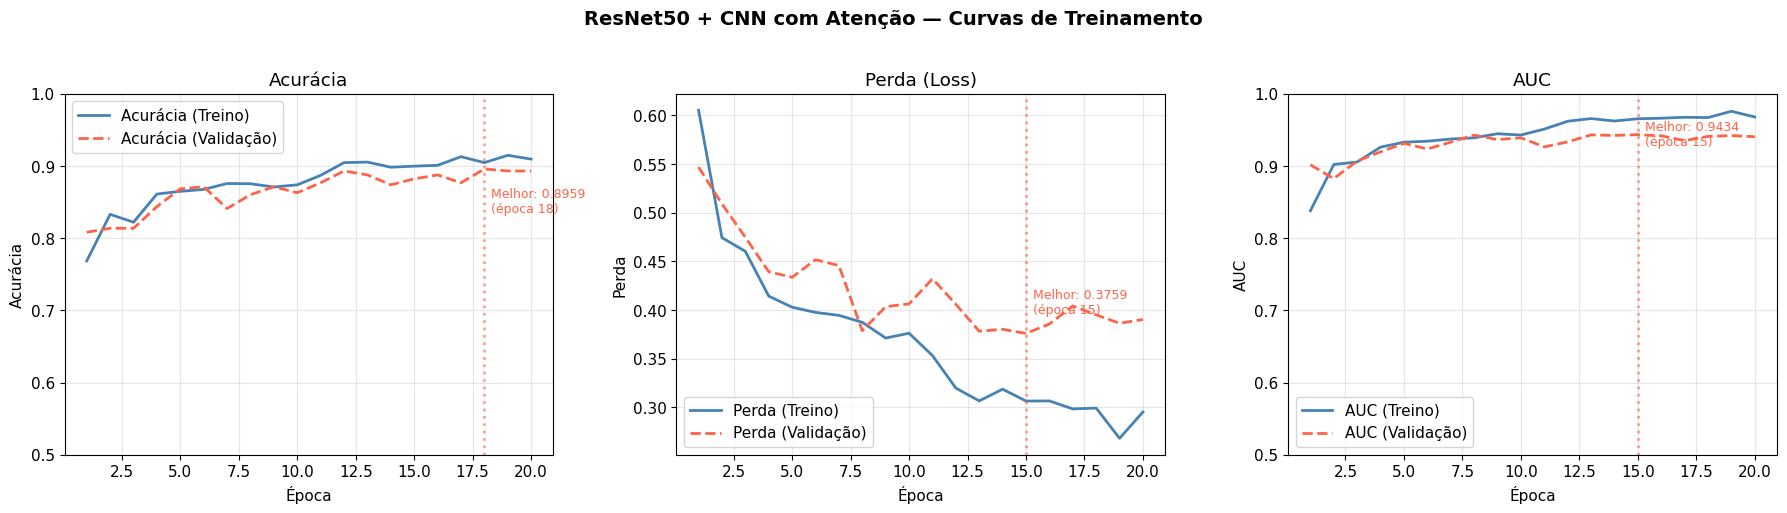


✓ Gráfico salvo → C:\Users\analice\Documents\TCC\resultados\resnet\curvas_treinamento.png


In [ ]:
# Plotar Curvas de Treinamento

RESULTS_DIR = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\resnet")

# Carregar histórico 
hist = pd.read_csv(RESULTS_DIR / "historico_treinamento.csv")
epochs = range(1, len(hist) + 1)
print(f"✓ Histórico carregado — {len(hist)} épocas")
print(hist.to_string())

# Estilo do gráfico 
plt.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "white",
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "lines.linewidth"  : 2,
    "font.size"        : 11,
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Título atualizado para ResNet50
fig.suptitle("ResNet50 + CNN com Atenção — Curvas de Treinamento", 
             fontsize=14, fontweight="bold", y=1.02)

# 1. Acurácia (Accuracy)
ax = axes[0]
ax.plot(epochs, hist["accuracy"],     label="Acurácia (Treino)", color="steelblue")
ax.plot(epochs, hist["val_accuracy"], label="Acurácia (Validação)", color="tomato",
        linestyle="--")

best_epoch = hist["val_accuracy"].idxmax() + 1
best_val   = hist["val_accuracy"].max()
ax.axvline(best_epoch, color="tomato", linestyle=":", alpha=0.6)
ax.annotate(f"Melhor: {best_val:.4f}\n(época {best_epoch})",
            xy=(best_epoch, best_val),
            xytext=(best_epoch + 0.3, best_val - 0.06),
            fontsize=9, color="tomato")

ax.set_title("Acurácia")
ax.set_xlabel("Época")
ax.set_ylabel("Acurácia")
ax.set_ylim(0.5, 1.0)
ax.legend()

# 2. Perda (Loss)
ax = axes[1]
ax.plot(epochs, hist["loss"],     label="Perda (Treino)", color="steelblue")
ax.plot(epochs, hist["val_loss"], label="Perda (Validação)", color="tomato",
        linestyle="--")

best_epoch = hist["val_loss"].idxmin() + 1
best_val   = hist["val_loss"].min()
ax.axvline(best_epoch, color="tomato", linestyle=":", alpha=0.6)
ax.annotate(f"Melhor: {best_val:.4f}\n(época {best_epoch})",
            xy=(best_epoch, best_val),
            xytext=(best_epoch + 0.3, best_val + 0.02),
            fontsize=9, color="tomato")

ax.set_title("Perda (Loss)")
ax.set_xlabel("Época")
ax.set_ylabel("Perda")
ax.legend()

# 3. AUC 
ax = axes[2]
ax.plot(epochs, hist["auc"],     label="AUC (Treino)", color="steelblue")
ax.plot(epochs, hist["val_auc"], label="AUC (Validação)", color="tomato",
        linestyle="--")

best_epoch = hist["val_auc"].idxmax() + 1
best_val   = hist["val_auc"].max()
ax.axvline(best_epoch, color="tomato", linestyle=":", alpha=0.6)
ax.annotate(f"Melhor: {best_val:.4f}\n(época {best_epoch})",
            xy=(best_epoch, best_val),
            xytext=(best_epoch + 0.3, best_val - 0.015),
            fontsize=9, color="tomato")

ax.set_title("AUC")
ax.set_xlabel("Época")
ax.set_ylabel("AUC")
ax.set_ylim(0.5, 1.0)
ax.legend()

plt.tight_layout()

# Salvar e Exibir
out_path = RESULTS_DIR / "curvas_treinamento.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")

plt.show()  # Abre a janela com o gráfico na sua tela
plt.close() # Limpa a memória depois que você fechar a janela

print(f"\n✓ Gráfico salvo → {out_path}")

✓ Pipeline de teste pronto — 538 amostras
✓ Melhor modelo carregado

 Avaliação no conjunto de teste 
17/17 ━━━━━━━━━━━━━━━━━━━━ 17s 857ms/step - accuracy: 0.9015 - auc: 0.9579 - loss: 0.3346

  Resultados:
    loss         : 0.3346
    compile_metrics : 0.9015

 Gerando previsões
17/17 ━━━━━━━━━━━━━━━━━━━━ 17s 929ms/step
  Amostras previstas                : 538
  Positivos (massa=1) previstos     : 269
  Negativos (calc=0) previstos      : 269

 Relatório de Classificação
                  precision    recall  f1-score   support

calcificação (0)     0.9033    0.9000    0.9017       270
       massa (1)     0.8996    0.9030    0.9013       268

        accuracy                         0.9015       538
       macro avg     0.9015    0.9015    0.9015       538
    weighted avg     0.9015    0.9015    0.9015       538

✓ Relatório salvo → C:\Users\analice\Documents\TCC\resultados\resnet\relatorio_classificacao.txt

 Matriz de Confusão & Métricas Médicas
  Matriz bruta:
  [[243  27]
 [ 2

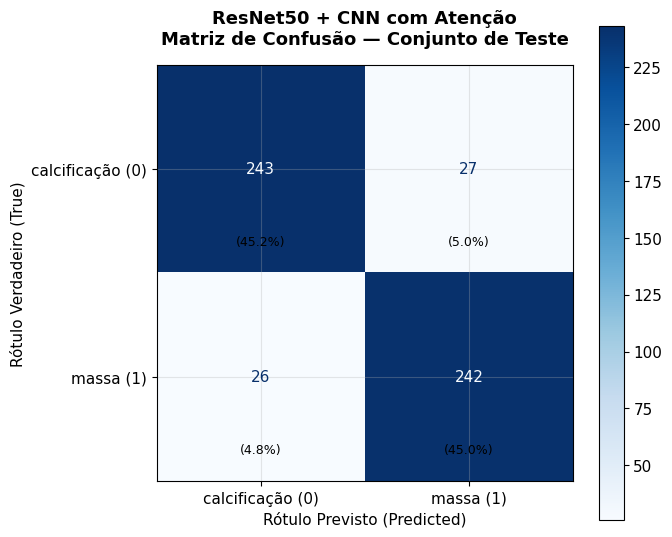

✓ Matriz de confusão salva → C:\Users\analice\Documents\TCC\resultados\resnet\matriz_confusao.png

 Resumo Final do Teste
  Teste loss         : 0.3346
  Teste compile_metrics : 0.9015

  Saídas salvas:
    📄 C:\Users\analice\Documents\TCC\resultados\resnet\relatorio_classificacao.txt
    🖼  C:\Users\analice\Documents\TCC\resultados\resnet\matriz_confusao.png

✓ Avaliação concluída.


In [ ]:
# Avaliação no Conjunto de Teste

RESULTS_DIR = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\resnet")

# 1. Reconstruir pipeline de teste 
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

test_df = pd.read_csv(RESULTS_DIR / "test_df.csv")

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

test_ds = (
    tf.data.Dataset.from_tensor_slices((
        test_df["image_path"].values,
        test_df["label"].values.astype("int32")
    ))
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
print(f"✓ Pipeline de teste pronto — {len(test_df)} amostras")

# 2. Carregar o melhor modelo
model = tf.keras.models.load_model(
    RESULTS_DIR / "best_model.keras",
    custom_objects={"preprocess_input": preprocess_input}
)
print(f"✓ Melhor modelo carregado")

# 3. Avaliar 
print(f"\n Avaliação no conjunto de teste ")
results = model.evaluate(test_ds, verbose=1)
metric_names = model.metrics_names

print(f"\n  Resultados:")
for name, val in zip(metric_names, results):
    print(f"    {name:<12} : {val:.4f}")

# 4. Gerar previsões 
print(f"\n Gerando previsões")
y_prob = model.predict(test_ds, verbose=1)       # probabilidades da sigmoid
y_pred = (y_prob.squeeze() >= 0.5).astype(int)   # limiar de 0.5
y_true = test_df["label"].values.astype(int)

print(f"  Amostras previstas                : {len(y_pred)}")
print(f"  Positivos (massa=1) previstos     : {y_pred.sum()}")
print(f"  Negativos (calc=0) previstos      : {(y_pred==0).sum()}")

# 5. Relatório de Classificação 
print(f"\n Relatório de Classificação")
label_names = ["calcificação (0)", "massa (1)"]
report = classification_report(y_true, y_pred, target_names=label_names, digits=4)
print(report)

report_path = RESULTS_DIR / "relatorio_classificacao.txt"
with open(report_path, "w", encoding="utf-8") as f:
    f.write("ResNet50 + CNN com Atenção\n")
    f.write("Relatório de Classificação - Conjunto de Teste\n")
    f.write("=" * 50 + "\n\n")
    f.write(report)

print(f"✓ Relatório salvo → {report_path}")

# 6. Matriz de Confusão e Métricas Médicas 
print(f"\n Matriz de Confusão & Métricas Médicas")
cm = confusion_matrix(y_true, y_pred)
print(f"  Matriz bruta:\n  {cm}")

# Extraindo os valores da matriz de confusão binária
TN, FP, FN, TP = cm.ravel()
sensibilidade = TP / (TP + FN) if (TP + FN) > 0 else 0
especificidade = TN / (TN + FP) if (TN + FP) > 0 else 0

print(f"\n  Sensibilidade (Recall para Massas)       : {sensibilidade:.4f}  (Taxa de Verdadeiros Positivos)")
print(f"  Especificidade (Recall para Calcificações) : {especificidade:.4f}  (Taxa de Verdadeiros Negativos)")

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, colorbar=True, cmap="Blues")

ax.set_title("ResNet50 + CNN com Atenção\nMatriz de Confusão — Conjunto de Teste",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Rótulo Previsto (Predicted)", fontsize=11)
ax.set_ylabel("Rótulo Verdadeiro (True)",      fontsize=11)

# Anotar com porcentagens
total = cm.sum()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        pct = cm[i, j] / total * 100
        ax.text(j, i + 0.35, f"({pct:.1f}%)", ha="center", va="center", fontsize=9, color="black")

plt.tight_layout()
cm_path = RESULTS_DIR / "matriz_confusao.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print(f"✓ Matriz de confusão salva → {cm_path}")

# 7. Resumo Final 
print(f"\n Resumo Final do Teste")
for name, val in zip(metric_names, results):
    print(f"  Teste {name:<12} : {val:.4f}")

print(f"\n  Saídas salvas:")
print(f"    📄 {report_path}")
print(f"    🖼  {cm_path}")

print(f"\n✓ Avaliação concluída.")

In [ ]:
# Fine-tuning — Descongelar Camadas Superiores da ResNet50

RESULTS_DIR = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\resnet")

# 1. Reconstruir pipelines (independente)
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

train_df = pd.read_csv(RESULTS_DIR / "train_df.csv")
val_df   = pd.read_csv(RESULTS_DIR / "val_df.csv")

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    img = tf.image.rot90(img, k)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def build_pipeline(df, training=False):
    ds = tf.data.Dataset.from_tensor_slices((
        df["image_path"].values,
        df["label"].values.astype("int32")
    ))
    if training:
        ds = ds.shuffle(len(df), seed=42, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = build_pipeline(train_df, training=True)
val_ds   = build_pipeline(val_df,   training=False)

print(f"✓ Pipelines prontos — treino:{len(train_df)}  val:{len(val_df)}")

# 2. Carregar o melhor modelo do baseline
# Adicionamos o custom_objects para a ResNet50
model = tf.keras.models.load_model(
    RESULTS_DIR / "best_model.keras",
    custom_objects={"preprocess_input": preprocess_input}
)
print(f"✓ Modelo baseline carregado")

# Métricas de validação do baseline (antes do fine-tuning) 
print(f"\n Métricas de validação do baseline (backbone congelado)")
base_results = model.evaluate(val_ds, verbose=0)
print(f"  Perda (Loss) val.  : {base_results[0]:.4f}")
print(f"  Acurácia val.      : {base_results[1]:.4f}")

# 3. Descongelar as últimas camadas da ResNet50 
# O índice do backbone na ResNet50 atual é o 3 (Input=0, Rescaling=1, Lambda=2, ResNet50=3)
backbone = model.layers[3]                                
total_backbone_layers = len(backbone.layers)

# Aumentamos para 40 camadas devido à profundidade da ResNet50
UNFREEZE_FROM = total_backbone_layers - 40                

backbone.trainable = True

for i, layer in enumerate(backbone.layers):
    if i < UNFREEZE_FROM:
        layer.trainable = False                           # manter congelado
    else:
        # Manter as camadas de BatchNorm congeladas — crítico para fine-tuning
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

unfrozen = sum(1 for l in backbone.layers if l.trainable)
print(f"\n Configuração do fine-tune do Backbone")
print(f"  Total de camadas do backbone : {total_backbone_layers}")
print(f"  Descongelando a partir de    : {UNFREEZE_FROM}")
print(f"  Camadas descongeladas        : {unfrozen}  (BatchNorm mantido congelado)")
print(f"  Camadas congeladas           : {total_backbone_layers - unfrozen}")

# 4. Recompilar com taxa de aprendizado (LR) baixa
FINETUNE_LR = 1e-4

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=FINETUNE_LR),
    loss      = "binary_crossentropy",
    metrics   = [
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

total     = model.count_params()
trainable = sum(tf.size(v).numpy() for v in model.trainable_variables)

print(f"\n  LR do Fine-tune          : {FINETUNE_LR}")
print(f"  Parâmetros treináveis    : {trainable:,}")
print(f"  Total de parâmetros      : {total:,}")

# 5. Callbacks para o fine-tuning 
ft_model_path = str(RESULTS_DIR / "best_model_finetuned.keras")

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor              = "val_loss",
        patience             = 4,
        restore_best_weights = True,
        verbose              = 1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor  = "val_loss",
        factor   = 0.3,
        patience = 2,
        min_lr   = 1e-7,
        verbose  = 1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath          = ft_model_path,
        monitor           = "val_auc",
        save_best_only    = True,
        save_weights_only = False,
        mode              = "max",
        verbose           = 1
    ),
]

# 6. Pesos das classes 
total_n = len(train_df)
n_calc  = (train_df["label"] == 0).sum()
n_mass  = (train_df["label"] == 1).sum()

class_weight = {0: total_n/(2*n_calc), 1: total_n/(2*n_mass)}

# 7. Treinamento (Fine-tuning)
print(f"\n Treinamento (Fine-tuning)")
print(f"  Épocas : até 12 (early stopping pode encerrar antes)\n")

ft_history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = 12, # Aumentei levemente para dar margem à ResNet50
    callbacks       = callbacks,
    class_weight    = class_weight,
    verbose         = 1
)

# 8. Comparar antes vs depois 
print(f"\n Antes vs Depois do Fine-tuning ")
ft_results  = model.evaluate(val_ds, verbose=0)

print(f"  {'Métrica':<15} {'Antes':>10} {'Depois':>10} {'Mudança':>10}")
print(f"  {'-'*50}")

metrics = ["val_loss", "val_accuracy", "val_auc"]
labels  = ["Perda (Loss)", "Acurácia", "AUC"]

for i, (label, before, after) in enumerate(zip(labels, base_results, ft_results)):
    arrow  = "⬆" if (after > before and i > 0) or (after < before and i == 0) else "⬇"
    change = after - before
    print(f"  {label:<15} {before:>10.4f} {after:>10.4f} {change:>+10.4f} {arrow}")

# Salvar histórico do fine-tuning 
ft_hist_df = pd.DataFrame(ft_history.history)
ft_hist_df.to_csv(RESULTS_DIR / "finetune_history.csv", index=False)

print(f"\n✓ Modelo fine-tuned salvo       → {ft_model_path}")
print(f"✓ Histórico fine-tuned salvo  → {RESULTS_DIR / 'finetune_history.csv'}")

✓ Pipelines prontos — treino:2665  val:365
✓ Modelo baseline carregado

 Métricas de validação do baseline (backbone congelado)
  Perda (Loss) val.  : 0.3759
  Acurácia val.      : 0.8822

 Configuração do fine-tune do Backbone
  Total de camadas do backbone : 175
  Descongelando a partir de    : 135
  Camadas descongeladas        : 28  (BatchNorm mantido congelado)
  Camadas congeladas           : 147

  LR do Fine-tune          : 0.0001
  Parâmetros treináveis    : 17,416,961
  Total de parâmetros      : 25,202,049

 Treinamento (Fine-tuning)
  Épocas : até 12 (early stopping pode encerrar antes)

Epoch 1/12
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8464 - auc: 0.9177 - loss: 0.4416
Epoch 1: val_auc improved from None to 0.94626, saving model to C:\Users\analice\Documents\TCC\resultados\resnet\best_model_finetuned.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.8559 - auc: 0.9271 - loss: 0.4161 - val_accuracy: 0.8027 - val_auc: 0.9463 - val_loss: 0.4439 - learni

✓ Épocas do baseline  : 20
✓ Épocas do fine-tune : 12
✓ Total de épocas     : 32
✓ Início do fine-tune : época 21


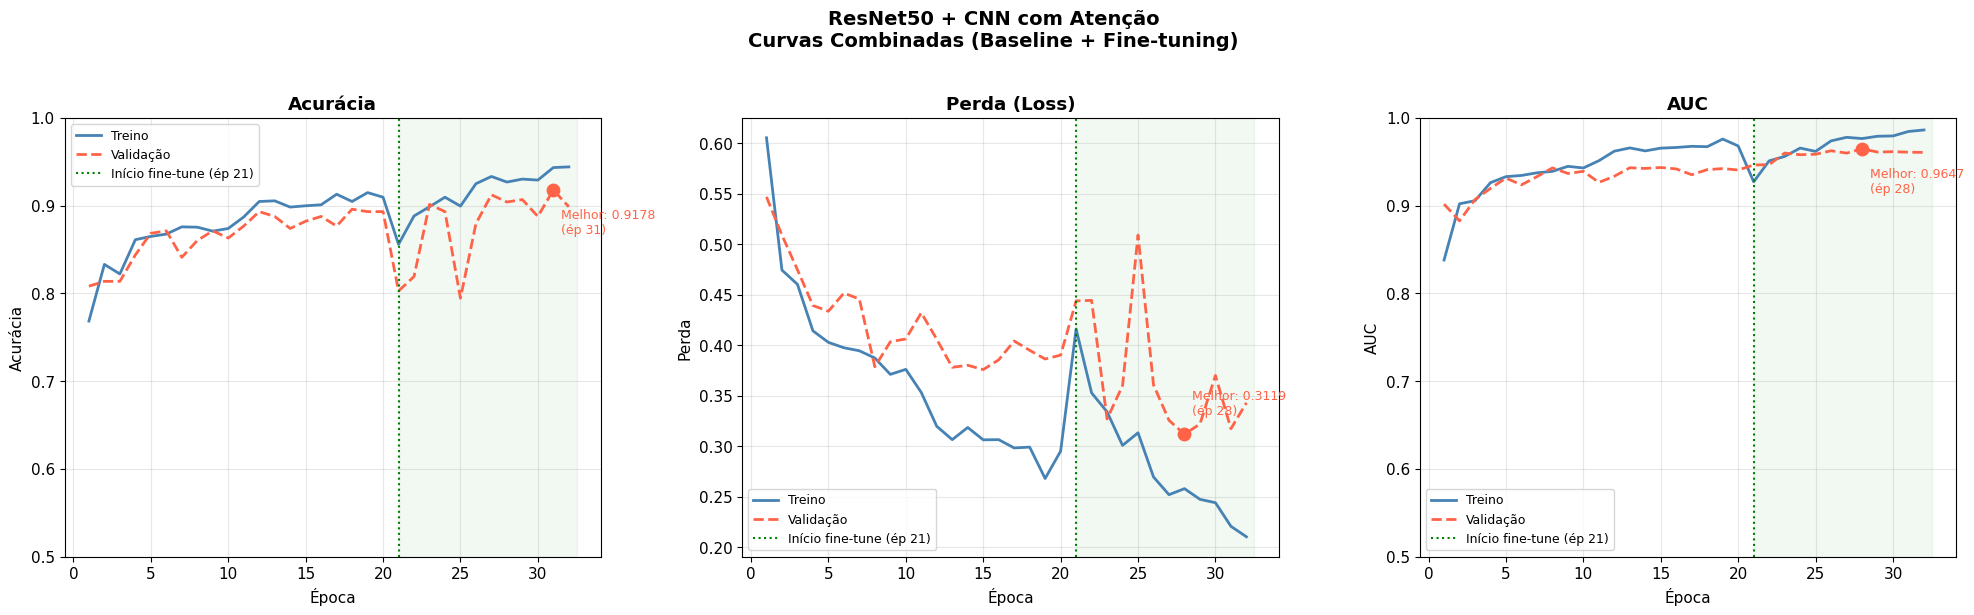


✓ Curvas combinadas salvas → C:\Users\analice\Documents\TCC\resultados\resnet\curvas_treinamento_combinadas.png

 Resumo completo do treinamento 
  Época    Acc Treino    Acc Val AUC Treino    AUC Val   Loss Val  Fase
  ---------------------------------------------------------------------------
  1            0.7685     0.8082     0.8380     0.9017     0.5469  baseline  
  2            0.8330     0.8137     0.9021     0.8826     0.5089  baseline  
  3            0.8221     0.8137     0.9056     0.9070     0.4747  baseline  
  4            0.8612     0.8438     0.9261     0.9196     0.4393  baseline  
  5            0.8649     0.8685     0.9330     0.9314     0.4337  baseline  
  6            0.8675     0.8712     0.9344     0.9236     0.4517  baseline  
  7            0.8758     0.8411     0.9374     0.9330     0.4457  baseline  
  8            0.8754     0.8603     0.9390     0.9429     0.3787  baseline  
  9            0.8709     0.8712     0.9447     0.9366     0.4035  baseline  
 

In [ ]:
# Curvas de Treinamento Combinadas (Baseline + Fine-tuning) 

RESULTS_DIR = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\resnet")

# Carregar ambos os históricos 
base_hist = pd.read_csv(RESULTS_DIR / "historico_treinamento.csv")
ft_hist   = pd.read_csv(RESULTS_DIR / "finetune_history.csv")

print(f"✓ Épocas do baseline  : {len(base_hist)}")
print(f"✓ Épocas do fine-tune : {len(ft_hist)}")

# Combinar 
combined = pd.concat([base_hist, ft_hist], ignore_index=True)
epochs         = range(1, len(combined) + 1)
finetune_start = len(base_hist) + 1     # época em que o fine-tuning começou

print(f"✓ Total de épocas     : {len(combined)}")
print(f"✓ Início do fine-tune : época {finetune_start}")

# Estilo do gráfico
plt.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "white",
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "lines.linewidth"  : 2,
    "font.size"        : 11,
})

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    "ResNet50 + CNN com Atenção\nCurvas Combinadas (Baseline + Fine-tuning)",
    fontsize=14, fontweight="bold", y=1.02)

def plot_metric(ax, train_col, val_col, title, ylabel, ylim=None):
    ax.plot(epochs, combined[train_col], label="Treino", color="steelblue")
    ax.plot(epochs, combined[val_col],   label="Validação", color="tomato",
            linestyle="--")

    # Marcador de início do fine-tune
    ax.axvline(finetune_start, color="green", linestyle=":",
               linewidth=1.5, label=f"Início fine-tune (ép {finetune_start})")
    ax.axvspan(finetune_start, len(combined) + 0.5,
               alpha=0.05, color="green")

    # Marcador do melhor valor de validação
    if "loss" in val_col:
        best_ep  = combined[val_col].idxmin() + 1
        best_val = combined[val_col].min()
    else:
        best_ep  = combined[val_col].idxmax() + 1
        best_val = combined[val_col].max()

    ax.scatter(best_ep, best_val, color="tomato", zorder=5, s=80)
    ax.annotate(f"Melhor: {best_val:.4f}\n(ép {best_ep})",
                xy=(best_ep, best_val),
                xytext=(best_ep + 0.5,
                        best_val - 0.05 if "loss" not in val_col else best_val + 0.02),
                fontsize=9, color="tomato")

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Época")
    ax.set_ylabel(ylabel)
    if ylim:
        ax.set_ylim(ylim)
    ax.legend(fontsize=9)

# 1. Acurácia
plot_metric(axes[0],
            train_col="accuracy",
            val_col  ="val_accuracy",
            title    ="Acurácia",
            ylabel   ="Acurácia",
            ylim     =(0.5, 1.0))

# 2. Perda (Loss)
plot_metric(axes[1],
            train_col="loss",
            val_col  ="val_loss",
            title    ="Perda (Loss)",
            ylabel   ="Perda")

# 3. AUC 
plot_metric(axes[2],
            train_col="auc",
            val_col  ="val_auc",
            title    ="AUC",
            ylabel   ="AUC",
            ylim     =(0.5, 1.0))

plt.tight_layout()

# Salvar e Exibir
out_path = RESULTS_DIR / "curvas_treinamento_combinadas.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print(f"\n✓ Curvas combinadas salvas → {out_path}")

# Imprimir tabela de resumo
print(f"\n Resumo completo do treinamento ")
print(f"  {'Época':<8} {'Acc Treino':>10} {'Acc Val':>10} "
      f"{'AUC Treino':>10} {'AUC Val':>10} {'Loss Val':>10}  Fase")
print(f"  {'-'*75}")

for i, row in combined.iterrows():
    phase = "baseline  " if i < len(base_hist) else "fine-tune "
    print(f"  {i+1:<8} {row['accuracy']:>10.4f} {row['val_accuracy']:>10.4f} "
          f"{row['auc']:>10.4f} {row['val_auc']:>10.4f} "
          f"{row['val_loss']:>10.4f}  {phase}")

✓ Modelo fine-tuned carregado com sucesso
17/17 ━━━━━━━━━━━━━━━━━━━━ 17s 949ms/step
✓ Previsões prontas — 538 amostras

 Informações da ROC
  Pontuação AUC (AUC score) : 0.9683
  Limiar (Threshold) ideal  : 0.3662
  FPR ideal                 : 0.0630
  TPR ideal                 : 0.9328


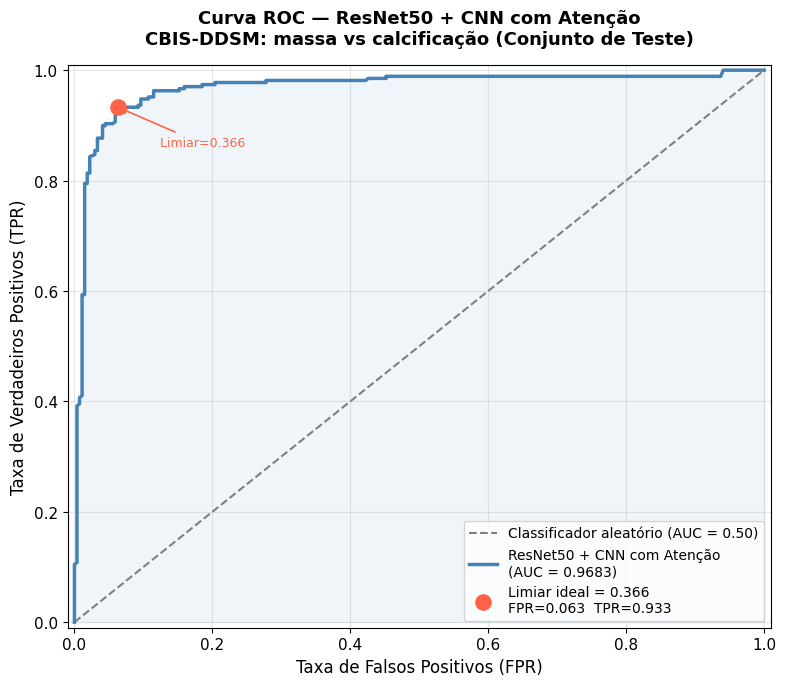


✓ Curva ROC salva → C:\Users\analice\Documents\TCC\resultados\resnet\curva_roc.png
   AUC = 0.9683


In [ ]:
# Curva ROC e Ajuste de Limiar 

RESULTS_DIR = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\resnet")

# 1. Reconstruir pipeline de teste 
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

test_df = pd.read_csv(RESULTS_DIR / "test_df.csv")

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    # Normalização padrão. A rede fará o preprocess_input internamente.
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

test_ds = (
    tf.data.Dataset.from_tensor_slices((
        test_df["image_path"].values,
        test_df["label"].values.astype("int32")
    ))
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# 2. Carregar o modelo final com o ajuste fino 
model = tf.keras.models.load_model(
    RESULTS_DIR / "best_model_finetuned.keras",
    custom_objects={"preprocess_input": preprocess_input}
)
print(f"✓ Modelo fine-tuned carregado com sucesso")

y_prob = model.predict(test_ds, verbose=1).squeeze()
y_true = test_df["label"].values.astype(int)

print(f"✓ Previsões prontas — {len(y_prob)} amostras")

# 3. Calcular curva ROC 
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
auc_score            = roc_auc_score(y_true, y_prob)

# Encontrar o limiar (threshold) ideal — ponto mais próximo do canto superior esquerdo (0, 1)
optimal_idx       = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
optimal_fpr       = fpr[optimal_idx]
optimal_tpr       = tpr[optimal_idx]

print(f"\n Informações da ROC")
print(f"  Pontuação AUC (AUC score) : {auc_score:.4f}")
print(f"  Limiar (Threshold) ideal  : {optimal_threshold:.4f}")
print(f"  FPR ideal                 : {optimal_fpr:.4f}")
print(f"  TPR ideal                 : {optimal_tpr:.4f}")

# 4. Plotar (Gráfico) 
fig, ax = plt.subplots(figsize=(8, 7))

# Linha base de um classificador aleatório
ax.plot([0, 1], [0, 1],
        color="grey", linestyle="--", linewidth=1.5,
        label="Classificador aleatório (AUC = 0.50)")

# Curva ROC do nosso modelo
ax.plot(fpr, tpr,
        color="steelblue", linewidth=2.5,
        label=f"ResNet50 + CNN com Atenção\n(AUC = {auc_score:.4f})")

# Ponto do limiar ideal
ax.scatter(optimal_fpr, optimal_tpr,
           color="tomato", zorder=5, s=120,
           label=f"Limiar ideal = {optimal_threshold:.3f}\n"
                 f"FPR={optimal_fpr:.3f}  TPR={optimal_tpr:.3f}")

# Anotação do ponto ideal
ax.annotate(f"  Limiar={optimal_threshold:.3f}",
            xy=(optimal_fpr, optimal_tpr),
            xytext=(optimal_fpr + 0.05, optimal_tpr - 0.07),
            fontsize=9, color="tomato",
            arrowprops=dict(arrowstyle="->", color="tomato", lw=1.2))

# Preencher a área sob a curva
ax.fill_between(fpr, tpr, alpha=0.08, color="steelblue")

ax.set_title(
    "Curva ROC — ResNet50 + CNN com Atenção\n"
    "CBIS-DDSM: massa vs calcificação (Conjunto de Teste)",
    fontsize=13, fontweight="bold", pad=15)

ax.set_xlabel("Taxa de Falsos Positivos (FPR)", fontsize=12)
ax.set_ylabel("Taxa de Verdadeiros Positivos (TPR)", fontsize=12)

ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()

# Salvar e exibir
out_path = RESULTS_DIR / "curva_roc.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print(f"\n✓ Curva ROC salva → {out_path}")
print(f"   AUC = {auc_score:.4f}")

 Contagem de Amostras por Divisão
  Treino       — calcificação: 1404  massa: 1261  total: 2665
  Validação    — calcificação:  198  massa:  167  total:  365
  Teste        — calcificação:  270  massa:  268  total:  538


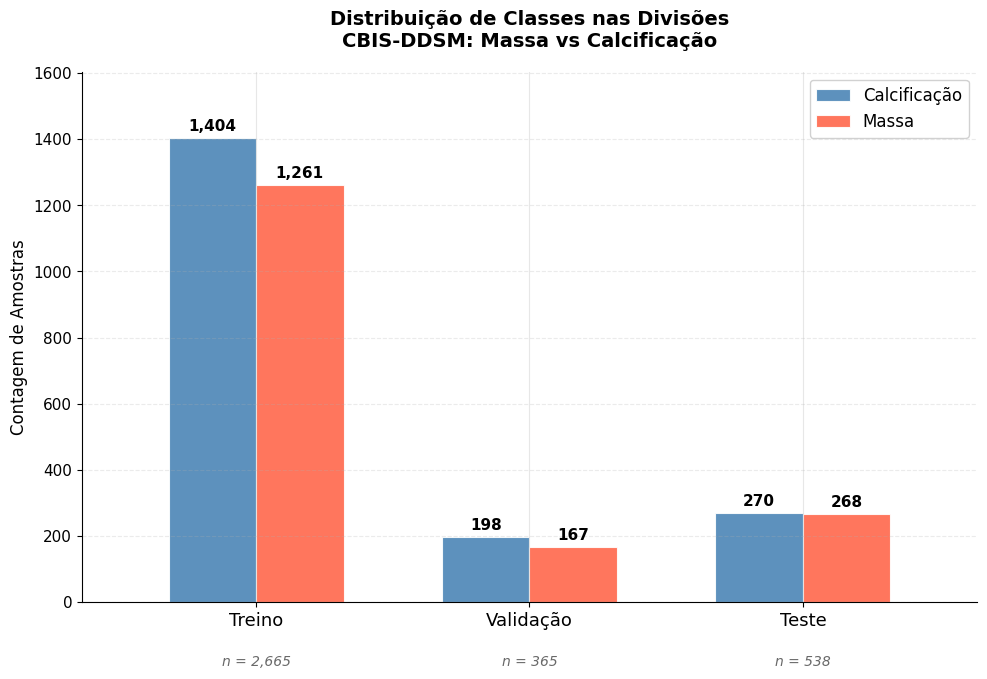


✓ Gráfico de distribuição de classes salvo → C:\Users\analice\Documents\TCC\resultados\resnet\distribuicao_classes.png


In [ ]:
# Gráfico de Distribuição de Classes

RESULTS_DIR = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\resnet")

# Carregar divisões
train_df = pd.read_csv(RESULTS_DIR / "train_df.csv")
val_df   = pd.read_csv(RESULTS_DIR / "val_df.csv")
test_df  = pd.read_csv(RESULTS_DIR / "test_df.csv")

splits = ["Treino", "Validação", "Teste"]
dfs    = [train_df, val_df, test_df]
counts = {}

print(f" Contagem de Amostras por Divisão")
for name, df in zip(splits, dfs):
    vc = df["lesion_type"].value_counts()
    counts[name] = {
        "calcification": int(vc.get("calcification", 0)),
        "mass"         : int(vc.get("mass", 0)),
        "total"        : len(df)
    }
    print(f"  {name:<12} — calcificação: {counts[name]['calcification']:>4}  "
          f"massa: {counts[name]['mass']:>4}  total: {counts[name]['total']:>4}")

# Plotar
x     = np.arange(len(splits))
width = 0.32

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

bars_calc = ax.bar(
    x - width/2,
    [counts[s]["calcification"] for s in splits],
    width, label="Calcificação",
    color="steelblue", edgecolor="white", linewidth=0.8, alpha=0.88
)

bars_mass = ax.bar(
    x + width/2,
    [counts[s]["mass"] for s in splits],
    width, label="Massa",
    color="tomato", edgecolor="white", linewidth=0.8, alpha=0.88
)

# Rótulos de contagem no topo das barras
for bar in list(bars_calc) + list(bars_mass):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2,
            h + 12,
            f"{int(h):,}",
            ha="center", va="bottom",
            fontsize=11, fontweight="bold", color="black")

# Rótulo de Total (n=) ABAIXO do eixo x (clip_on=False)
for i, s in enumerate(splits):
    ax.annotate(
        f"n = {counts[s]['total']:,}",
        xy=(i, 0),
        xytext=(0, -38),                      # 38 pontos abaixo da linha do eixo x
        textcoords="offset points",
        ha="center", va="top",
        fontsize=10, color="dimgray",
        style="italic",
        annotation_clip=False                 # permite desenhar fora da caixa dos eixos
    )

# Formatação
ax.set_title(
    "Distribuição de Classes nas Divisões\n"
    "CBIS-DDSM: Massa vs Calcificação",
    fontsize=14, fontweight="bold", pad=18)

ax.set_xticks(x)
ax.set_xticklabels(splits, fontsize=13)
ax.set_ylabel("Contagem de Amostras", fontsize=12)

ax.set_ylim(0, max(counts["Treino"]["calcification"],
                   counts["Treino"]["mass"]) + 200)

ax.legend(fontsize=12, framealpha=0.9)
ax.grid(axis="y", alpha=0.25, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.margins(x=0.12)

plt.tight_layout()
plt.subplots_adjust(bottom=0.13)             # espaço extra para os rótulos de n=

# Salvar e Exibir
out_path = RESULTS_DIR / "distribuicao_classes.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print(f"\n✓ Gráfico de distribuição de classes salvo → {out_path}")

Colunas : ['patient_id', 'lesion_type', 'pathology', 'image_path', 'left_or_right_breast', 'image_view', 'label']
Exemplos de valores image_path:
 ['C:\\Users\\analice\\Documents\\TCC\\dataset\\jpeg\\1.3.6.1.4.1.9590.100.1.2.141269558913652553006787176281528676980\\1-223.jpg', 'C:\\Users\\analice\\Documents\\TCC\\dataset\\jpeg\\1.3.6.1.4.1.9590.100.1.2.181380004612430571924629395230074095682\\1-222.jpg', 'C:\\Users\\analice\\Documents\\TCC\\dataset\\jpeg\\1.3.6.1.4.1.9590.100.1.2.81595047412515733434402090860388891176\\1-230.jpg']

Primeiro caminho resolvido : C:\Users\analice\Documents\TCC\dataset\jpeg\1.3.6.1.4.1.9590.100.1.2.141269558913652553006787176281528676980\1-223.jpg
Existe                     : True

 Gerando previsões para a grade 
  Corretos : 499  |  Classificados incorretamente : 39


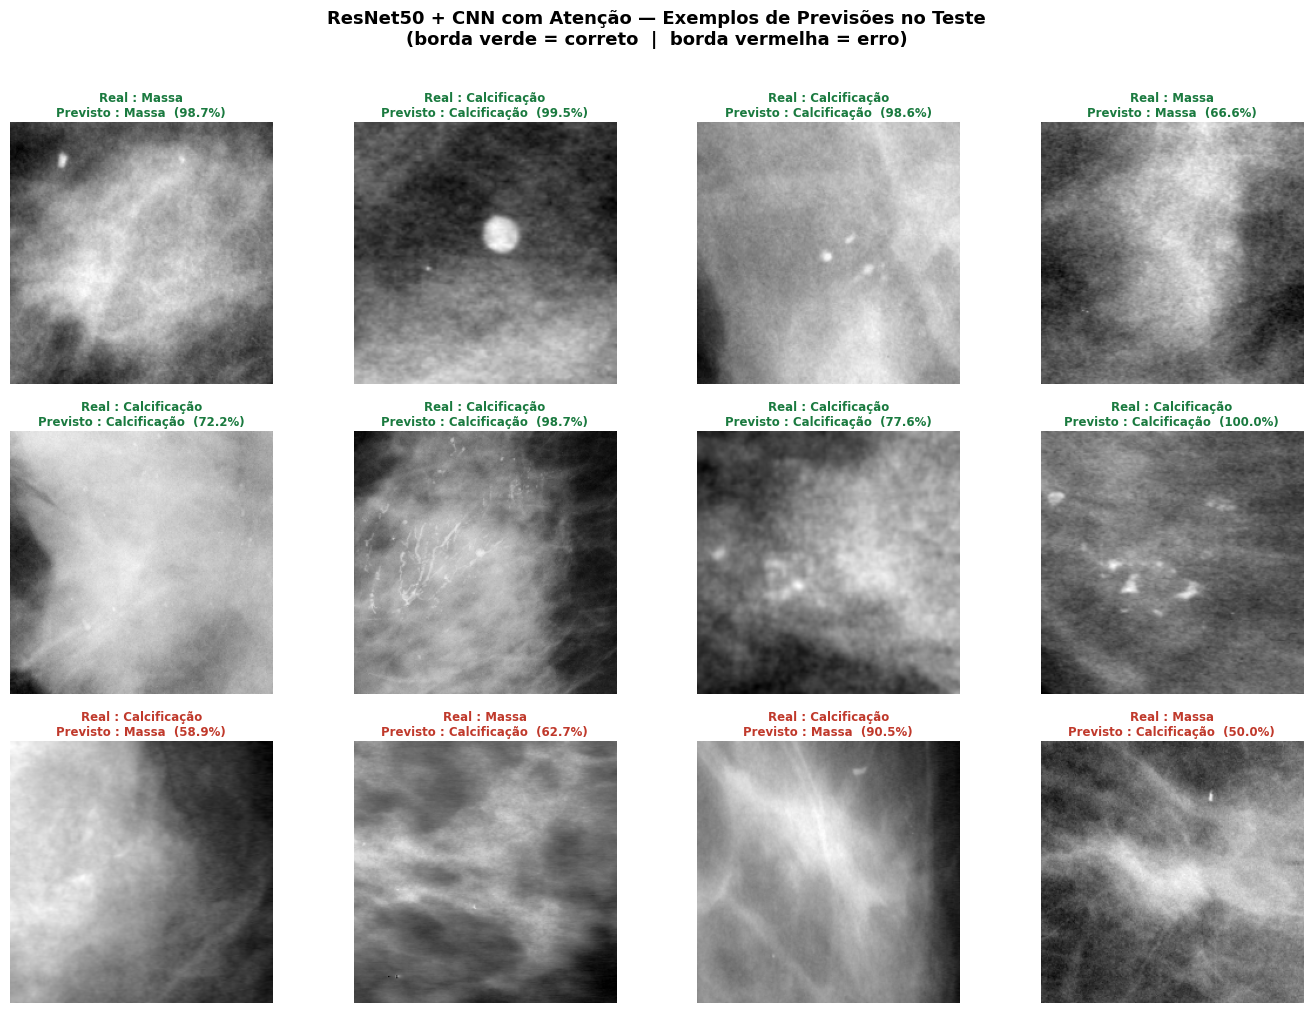


✓ Grade de previsões de exemplo salva → C:\Users\analice\Documents\TCC\resultados\resnet\previsoes_amostra.png


In [ ]:
# Grade de Previsões de Exemplo 

RESULTS_DIR  = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\resnet")
DATASET_ROOT = pathlib.Path(r"C:\Users\analice\Documents\TCC\dataset")

IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
SEED         = 42

# 1. Carregar modelo & divisão de teste 
# Importante: lembrar do custom_objects para a ResNet50
model   = tf.keras.models.load_model(
    RESULTS_DIR / "best_model_finetuned.keras",
    custom_objects={"preprocess_input": preprocess_input}
)
test_df = pd.read_csv(RESULTS_DIR / "test_df.csv")

print("Colunas :", test_df.columns.tolist())
print("Exemplos de valores image_path:\n", test_df["image_path"].head(3).tolist())

# 2. Resolver caminhos absolutos 
def resolve_path(p):
    path_obj = pathlib.Path(str(p))
    if path_obj.is_absolute():
        return str(path_obj)                # já é absoluto (ex: C:\...)
    return str(DATASET_ROOT / path_obj)     # adiciona a raiz do dataset se for relativo

paths     = [resolve_path(p) for p in test_df["image_path"].tolist()]
true_ints = np.array([int(l) for l in test_df["label"].tolist()])

# Verificação de sanidade
first = pathlib.Path(paths[0])
print(f"\nPrimeiro caminho resolvido : {first}")
print(f"Existe                     : {first.exists()}")
assert first.exists(), "✗ Caminho ainda não encontrado — verifique o DATASET_ROOT ou os valores da coluna."

label_map     = {"calcification": 0, "mass": 1}
inv_label_map = {0: "Calcificação", 1: "Massa"}

# 3. Função auxiliar para decodificar imagem
def decode_image(path):
    raw = tf.io.read_file(path)
    img = tf.image.decode_jpeg(raw, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    # A normalização [0,1] é mantida, o modelo faz o resto internamente
    img = tf.cast(img, tf.float32) / 255.0
    return img

# 4. Inferência em lote (Batch inference)
all_probs = []
ds = (tf.data.Dataset.from_tensor_slices(paths)
        .map(decode_image, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE))

print(f"\n Gerando previsões para a grade ")
for batch in ds:
    preds = model.predict(batch, verbose=0)
    all_probs.extend(preds.flatten().tolist())

all_probs    = np.array(all_probs)
pred_ints    = (all_probs >= 0.5).astype(int)

correct_mask = pred_ints == true_ints
correct_idx  = np.where(correct_mask)[0].tolist()
wrong_idx    = np.where(~correct_mask)[0].tolist()

print(f"  Corretos : {len(correct_idx)}  |  Classificados incorretamente : {len(wrong_idx)}")

# Escolher amostras: até 4 erradas + restante certas (12 no total)
random.seed(SEED)
n_wrong        = min(4, len(wrong_idx))
n_correct      = 12 - n_wrong

chosen_correct = random.sample(correct_idx, min(n_correct, len(correct_idx)))
chosen_wrong   = random.sample(wrong_idx,   n_wrong)
sample_idx     = chosen_correct + chosen_wrong

# 5. Plotar grade 3×4 
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.patch.set_facecolor("white")
fig.suptitle("ResNet50 + CNN com Atenção — Exemplos de Previsões no Teste\n"
             "(borda verde = correto  |  borda vermelha = erro)",
             fontsize=13, fontweight="bold", y=1.01)

for ax, i in zip(axes.flatten(), sample_idx):
    img_np   = decode_image(paths[i]).numpy()
    true_lbl = inv_label_map[true_ints[i]]
    pred_lbl = inv_label_map[pred_ints[i]]
    prob     = all_probs[i] if pred_ints[i] == 1 else 1 - all_probs[i]
    is_ok    = correct_mask[i]

    ax.imshow(img_np)
    ax.axis("off")
    
    # Adicionar bordas coloridas
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(3.5)
        spine.set_edgecolor("#2ecc71" if is_ok else "#e74c3c")
        
    ax.set_title(
        f"Real : {true_lbl}\nPrevisto : {pred_lbl}  ({prob*100:.1f}%)",
        fontsize=8.5, fontweight="bold", pad=4,
        color="#1a7a3f" if is_ok else "#c0392b"
    )

# Esconder eixos sobressalentes, caso existam
for ax in axes.flatten()[len(sample_idx):]:
    ax.set_visible(False)

plt.tight_layout()

# Salvar e Exibir
out_path = RESULTS_DIR / "previsoes_amostra.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print(f"\n✓ Grade de previsões de exemplo salva → {out_path}")

 Conv alvo (alvo do gradiente) : conv5_block3_out 

  Sucesso do Grad-CAM: 8/8  |  Falhas/Fallback: 0/8


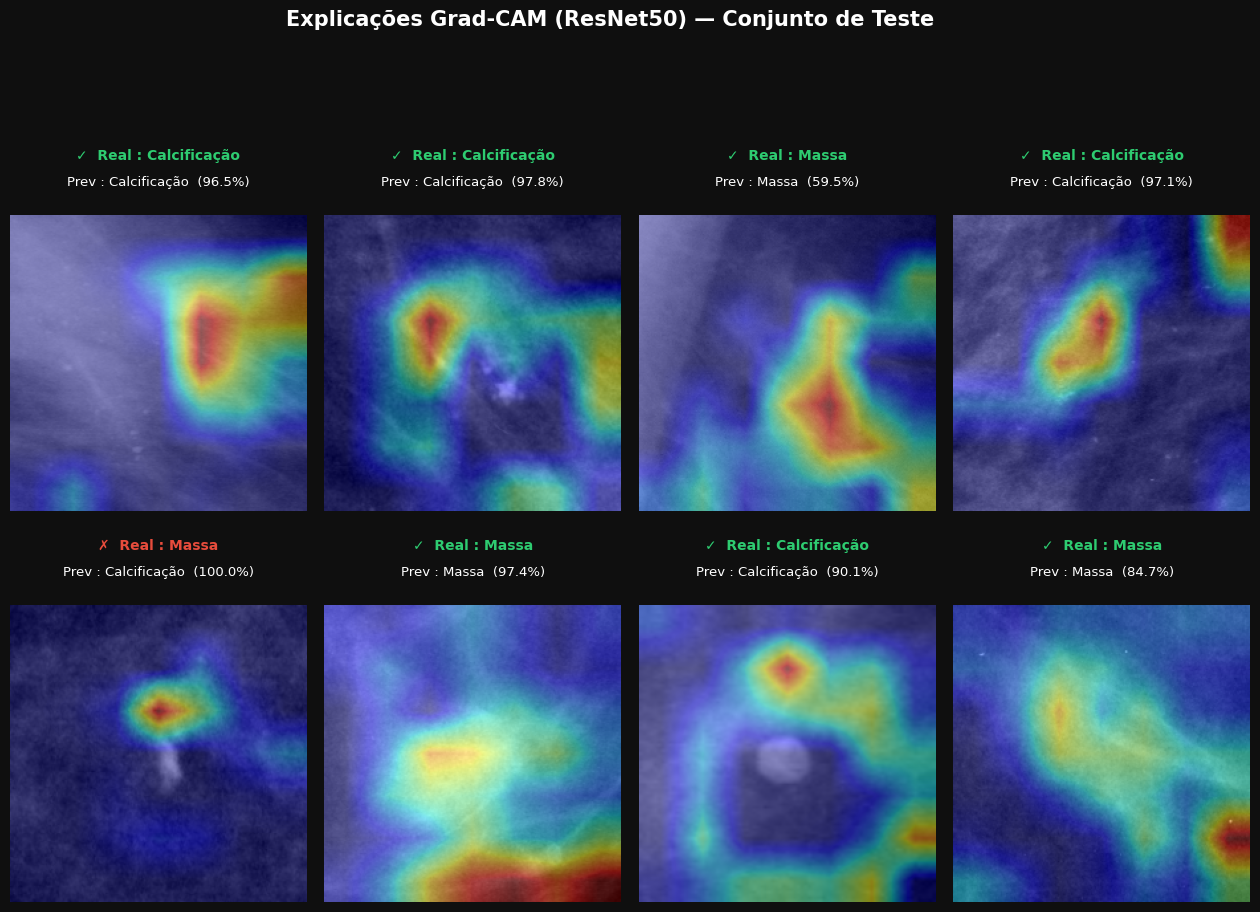

✓ Grad-CAM salvo → C:\Users\analice\Documents\TCC\resultados\resnet\gradcam_examples.png


In [ ]:
# Visualizações Grad-CAM (ResNet50) 

# Alterado para a pasta da ResNet50
RESULTS_DIR  = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\resnet")
DATASET_ROOT = pathlib.Path(r"C:\Users\analice\Documents\TCC\dataset")

IMG_SIZE    = (224, 224)
SEED        = 42
N_SAMPLES   = 8

# 1. Carregar modelo e divisão de teste
model = tf.keras.models.load_model(
    RESULTS_DIR / "best_model_finetuned.keras",
    custom_objects={"preprocess_input": preprocess_input}
)
test_df = pd.read_csv(RESULTS_DIR / "test_df.csv")

inv_label = {0: "Calcificação", 1: "Massa"}

# Função para resolver caminhos do Windows
def resolve_path(p):
    path_obj = pathlib.Path(str(p))
    if path_obj.is_absolute():
        return str(path_obj)
    return str(DATASET_ROOT / path_obj)

# 2. Mapeamento das Camadas do Modelo
# O modelo principal (ResNet50_AttentionCNN) contém as seguintes camadas principais:
# 0: input
# 1: rescaling
# 2: lambda (preprocess_input)
# 3: resnet50 (o backbone em si)
# 4...: Camadas de atenção (gap, dense, multiply)
# N...: GlobalAvgPool, BatchNorm, Dropout, Dense (Cabeçalho)

l_rescale  = model.layers[1]
l_lambda   = model.layers[2]
resnet_net = model.layers[3]

def find_layer(name_substring, index=0):
    found = [l for l in model.layers if name_substring in l.name]
    return found[index]

# Identificar o fluxo de atenção e cabeçalho pelo nome
l_gap_att    = find_layer("global_average_pooling2d", index=0)
l_reshape    = find_layer("reshape")
l_dense_att1 = find_layer("dense", index=0)
l_dense_att2 = find_layer("dense", index=1)
l_multiply   = find_layer("multiply")
l_gap_head   = find_layer("global_average_pooling2d", index=1)
l_bn         = find_layer("batch_normalization")
l_drop1      = find_layer("dropout", index=0)
l_dense_h1   = find_layer("dense", index=2)
l_drop2      = find_layer("dropout", index=1)
l_dense_h2   = find_layer("dense", index=3)
l_drop3      = find_layer("dropout", index=2)
l_out        = find_layer("output")

# 3. Submodelo Grad-CAM da ResNet50 
# A última camada convolucional útil da ResNet50 é o último bloco (conv5_block3_out)
last_conv_name = next(
    l.name for l in reversed(resnet_net.layers)
    if isinstance(l, tf.keras.layers.Activation) or isinstance(l, tf.keras.layers.Add)
)
print(f" Conv alvo (alvo do gradiente) : {last_conv_name} ")

resnet_gradcam = tf.keras.Model(
    inputs  = resnet_net.inputs,
    outputs = [resnet_net.get_layer(last_conv_name).output, resnet_net.output]
)

# 4. Função Grad-CAM Adaptada 
@tf.function # Otimização de performance
def compute_gradcam(img_tensor):
    # Pre-processamento
    x = l_rescale(img_tensor, training=False)
    x = l_lambda(x, training=False)
    
    with tf.GradientTape() as tape:
        conv_out, resnet_out = resnet_gradcam(x, training=False)
        tape.watch(conv_out)
        
        # Fluxo de Atenção Squeeze-and-Excitation
        h = l_gap_att(resnet_out, training=False)
        h = l_reshape(h, training=False)
        r = h
        h = l_dense_att1(h, training=False)
        h = l_dense_att2(h, training=False)
        h = l_multiply([resnet_out, h], training=False) # Multiplica pelo mapa original
        
        # Cabeçalho de Classificação
        h = l_gap_head(h, training=False)
        h = l_bn(h, training=False)
        h = l_drop1(h, training=False)
        h = l_dense_h1(h, training=False)
        h = l_drop2(h, training=False)
        h = l_dense_h2(h, training=False)
        h = l_drop3(h, training=False)
        score = l_out(h, training=False)[:, 0]
        
    grads   = tape.gradient(score, conv_out)
    weights = tf.reduce_mean(grads, axis=(1, 2))[0]
    cam     = tf.nn.relu(tf.reduce_sum(conv_out[0] * weights, axis=-1))
    return cam

def get_gradcam(img_np):
    inp = tf.constant(img_np[np.newaxis], dtype=tf.float32)
    cam = compute_gradcam(inp).numpy()
    
    # Normalização
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    cam = tf.image.resize(cam[..., np.newaxis], IMG_SIZE).numpy()[..., 0]
    return cam

def make_overlay(img_np, cam):
    # Usamos plt.get_cmap('jet') para evitar conflito com a variável 'cm' da Matriz de Confusão
    colormap = plt.get_cmap('jet')
    return (0.55 * img_np + 0.45 * colormap(cam)[..., :3]).clip(0, 1)

def load_img(path):
    real_path = resolve_path(path)
    raw = tf.io.read_file(real_path)
    img = tf.image.decode_jpeg(raw, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return (tf.cast(img, tf.float32) / 255.0).numpy()

# 5. Seleção de Amostras 
random.seed(SEED)
calc_idx = test_df[test_df["label"] == 0].index.tolist()
mass_idx = test_df[test_df["label"] == 1].index.tolist()

chosen   = (random.sample(calc_idx, N_SAMPLES // 2) +
            random.sample(mass_idx, N_SAMPLES // 2))
random.shuffle(chosen)

# 6. Plotar Grade (Visualização) 
n_cols = 4
n_rows = (N_SAMPLES + n_cols - 1) // n_cols

hr = []
for _ in range(n_rows):
    hr += [0.18, 1.0]

fig = plt.figure(figsize=(16, n_rows * 5), facecolor="#0f0f0f")
fig.suptitle("Explicações Grad-CAM (ResNet50) — Conjunto de Teste",
             fontsize=15, fontweight="bold", color="white", y=1.01)

gs = gridspec.GridSpec(n_rows * 2, n_cols, figure=fig,
                       hspace=0.06, wspace=0.06, height_ratios=hr)

n_ok, n_fail = 0, 0
for i, idx in enumerate(chosen):
    col      = i % n_cols
    rp       = i // n_cols
    row      = test_df.iloc[idx]
    true_int = int(row["label"])
    
    img_np   = load_img(row["image_path"])
    inp_t    = tf.constant(img_np[np.newaxis], dtype=tf.float32)
    prob     = float(model(inp_t, training=False).numpy()[0, 0])
    pred_int = int(prob >= 0.5)
    conf     = prob if pred_int == 1 else 1 - prob
    
    is_ok    = pred_int == true_int
    bc       = "#2ecc71" if is_ok else "#e74c3c"
    status   = "✓" if is_ok else "✗"

    try:
        cam     = get_gradcam(img_np)
        overlay = make_overlay(img_np, cam)
        n_ok   += 1
    except Exception as e:
        print(f"  ⚠ idx {idx}: Erro no cálculo ({e})")
        overlay = img_np
        n_fail += 1

    ax_lbl = fig.add_subplot(gs[rp * 2, col])
    ax_lbl.set_facecolor("#1a1a1a")
    ax_lbl.axis("off")
    ax_lbl.text(0.5, 0.72, f"{status}  Real : {inv_label[true_int]}",
                ha="center", va="center", fontsize=10,
                fontweight="bold", color=bc, transform=ax_lbl.transAxes)
    ax_lbl.text(0.5, 0.25, f"Prev : {inv_label[pred_int]}  ({conf*100:.1f}%)",
                ha="center", va="center", fontsize=9.5,
                color="white", transform=ax_lbl.transAxes)
    for sp in ax_lbl.spines.values():
        sp.set_visible(True); sp.set_linewidth(2.5); sp.set_edgecolor(bc)

    ax_img = fig.add_subplot(gs[rp * 2 + 1, col])
    ax_img.imshow(overlay); ax_img.axis("off")
    for sp in ax_img.spines.values():
        sp.set_visible(True); sp.set_linewidth(2.5); sp.set_edgecolor(bc)

print(f"\n  Sucesso do Grad-CAM: {n_ok}/{N_SAMPLES}  |  Falhas/Fallback: {n_fail}/{N_SAMPLES}")

# Salvar e Exibir
out_path = RESULTS_DIR / "gradcam_examples.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
plt.close()

print(f"✓ Grad-CAM salvo → {out_path}")

✓ Pipeline de teste pronto — 538 amostras
✓ Modelo fine-tuned carregado

 Gerando previsões
17/17 ━━━━━━━━━━━━━━━━━━━━ 17s 949ms/step
  Total de amostras  : 538
  Massa(1) prevista  : 253
  Calc(0) prevista   : 285

 Métricas Finais de Teste 
  Perda (Loss) de teste : 0.2389
  Acurácia de teste     : 0.9275  (92.75%)
  AUC de teste          : 0.9683  ← sklearn (confiável)

── Baseline vs Fine-tuned (Conjunto de Teste)
  Métrica           Baseline   Fine-tuned
  ---------------------------------------------
  Acurácia            0.8996       0.9275  ⬆
  Perda (Loss)        0.3415       0.2389  ⬆
  AUC (sklearn)          N/A       0.9683

 Relatório de Classificação
                  precision    recall  f1-score   support

calcificação (0)     0.9053    0.9556    0.9297       270
       massa (1)     0.9526    0.8993    0.9251       268

        accuracy                         0.9275       538
       macro avg     0.9289    0.9274    0.9274       538
    weighted avg     0.9288    0.92

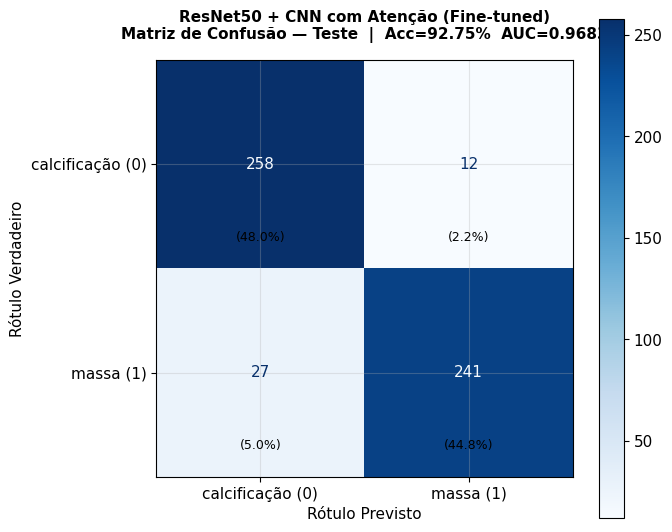

✓ Matriz de confusão salva → C:\Users\analice\Documents\TCC\resultados\resnet\matriz_confusao_finetuned.png
\ Todos os arquivos salvos
  📄 best_model.keras                              114391.3 KB
  📄 best_model_finetuned.keras                    240855.6 KB
  📄 classification_report_finetuned.txt                0.7 KB
  📄 curva_roc.png                                    102.2 KB
  📄 curvas_treinamento.png                           150.4 KB
  📄 curvas_treinamento_combinadas.png                197.3 KB
  📄 distribuicao_classes.png                          69.5 KB
  📄 finetune_history.csv                               1.7 KB
  📄 gradcam_examples.png                            1631.6 KB
  📄 historico_treinamento.csv                          2.8 KB
  📄 indice_arquivos.csv                              570.8 KB
  📄 matriz_confusao.png                               61.0 KB
  📄 matriz_confusao_finetuned.png                     58.1 KB
  📄 previsoes_amostra.png                           1189.2 

In [ ]:
# Avaliação Final no Conjunto de Teste (Modelo Fine-tuned) 

# Alterado para a pasta da ResNet50
RESULTS_DIR = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\resnet")

# 1. Reconstruir pipeline de teste 
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

test_df = pd.read_csv(RESULTS_DIR / "test_df.csv")

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    # A normalização padrão [0,1] — a rede faz o preprocess_input internamente
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

test_ds = (
    tf.data.Dataset.from_tensor_slices((
        test_df["image_path"].values,
        test_df["label"].values.astype("int32")
    ))
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print(f"✓ Pipeline de teste pronto — {len(test_df)} amostras")

# 2. Carregar o modelo fine-tuned
# O custom_objects é obrigatório para a ResNet50
model = tf.keras.models.load_model(
    RESULTS_DIR / "best_model_finetuned.keras",
    custom_objects={"preprocess_input": preprocess_input}
)
print(f"✓ Modelo fine-tuned carregado")

# 3. Gerar previsões 
print(f"\n Gerando previsões")
y_prob = model.predict(test_ds, verbose=1).squeeze()
y_pred = (y_prob >= 0.5).astype(int)
y_true = test_df["label"].values.astype(int)

print(f"  Total de amostras  : {len(y_pred)}")
print(f"  Massa(1) prevista  : {y_pred.sum()}")
print(f"  Calc(0) prevista   : {(y_pred==0).sum()}")

# 4. Métricas Finais
print(f"\n Métricas Finais de Teste ")
test_loss     = tf.keras.losses.binary_crossentropy(
                    y_true.astype("float32"),
                    y_prob.astype("float32")
                ).numpy().mean()

test_accuracy = (y_pred == y_true).mean()
test_auc      = roc_auc_score(y_true, y_prob)   # sklearn — sempre correto e confiável

print(f"  Perda (Loss) de teste : {test_loss:.4f}")
print(f"  Acurácia de teste     : {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)")
print(f"  AUC de teste          : {test_auc:.4f}  ← sklearn (confiável)")

# Comparar baseline vs fine-tuned no conjunto de teste 
print(f"\n── Baseline vs Fine-tuned (Conjunto de Teste)")
print(f"  {'Métrica':<15} {'Baseline':>10} {'Fine-tuned':>12}")
print(f"  {'-'*45}")

# NOTA: Atualize base_acc e base_loss com os valores reais da sua Célula 11
base_acc  = 0.8996 
base_loss = 0.3415

print(f"  {'Acurácia':<15} {base_acc:>10.4f} {test_accuracy:>12.4f}  "
      f"{'⬆' if test_accuracy > base_acc else '⬇'}")
print(f"  {'Perda (Loss)':<15} {base_loss:>10.4f} {test_loss:>12.4f}  "
      f"{'⬆' if test_loss < base_loss else '⬇'}")
print(f"  {'AUC (sklearn)':<15} {'N/A':>10} {test_auc:>12.4f}")

# 5. Relatório de Classificação e Métricas Médicas 
print(f"\n Relatório de Classificação")
label_names = ["calcificação (0)", "massa (1)"]
report      = classification_report(y_true, y_pred, target_names=label_names, digits=4)
print(report)

cm = confusion_matrix(y_true, y_pred)
TN, FP, FN, TP = cm.ravel()
sensibilidade = TP / (TP + FN) if (TP + FN) > 0 else 0
especificidade = TN / (TN + FP) if (TN + FP) > 0 else 0

print(f"\n Métricas Médicas ")
print(f"  Sensibilidade (Recall p/ Massas)         : {sensibilidade:.4f} (Verdadeiros Positivos)")
print(f"  Especificidade (Recall p/ Calcificações) : {especificidade:.4f} (Verdadeiros Negativos)")

report_path = RESULTS_DIR / "classification_report_finetuned.txt"
with open(report_path, "w", encoding="utf-8") as f:
    f.write("ResNet50 + CNN com Atenção — Fine-tuned\n")
    f.write("Relatório de Classificação do Conjunto de Teste\n")
    f.write("=" * 50 + "\n\n")
    f.write(f"Perda (Loss) Teste : {test_loss:.4f}\n")
    f.write(f"Acurácia Teste     : {test_accuracy:.4f}\n")
    f.write(f"AUC Teste          : {test_auc:.4f}\n\n")
    f.write(f"Sensibilidade      : {sensibilidade:.4f}\n")
    f.write(f"Especificidade     : {especificidade:.4f}\n\n")
    f.write(report)

print(f"\n✓ Relatório salvo → {report_path}")

# 6. Matriz de Confusão 
print(f"\n Matriz de Confusão")
print(f"  Bruta:\n  {cm}")

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, colorbar=True, cmap="Blues")

ax.set_title(
    f"ResNet50 + CNN com Atenção (Fine-tuned)\n"
    f"Matriz de Confusão — Teste  |  Acc={test_accuracy*100:.2f}%  AUC={test_auc:.4f}",
    fontsize=11, fontweight="bold", pad=15)
ax.set_xlabel("Rótulo Previsto", fontsize=11)
ax.set_ylabel("Rótulo Verdadeiro",      fontsize=11)

# Adicionar anotações de porcentagem
total = cm.sum()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        pct = cm[i, j] / total * 100
        ax.text(j, i + 0.35, f"({pct:.1f}%)", ha="center", va="center", fontsize=9, color="black")

plt.tight_layout()
cm_path = RESULTS_DIR / "matriz_confusao_finetuned.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print(f"✓ Matriz de confusão salva → {cm_path}")

# 7. Resumo Final de Arquivos 
print(f"\ Todos os arquivos salvos")
for f in sorted(RESULTS_DIR.iterdir()):
    size_kb = f.stat().st_size / 1e3
    print(f"  📄 {f.name:<45} {size_kb:>8.1f} KB")

print(f"\n✓ Avaliação final concluída com sucesso.")

In [ ]:
# Tabela de Resumo Final

# Alterado para a pasta da ResNet50
RESULTS_DIR = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\resnet")
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32

# 1. Carregar dados 
test_df   = pd.read_csv(RESULTS_DIR / "test_df.csv")
paths     = test_df["image_path"].tolist()

# Usa a raiz do dataset caso os caminhos não estejam absolutos
DATASET_ROOT = pathlib.Path(r"C:\Users\analice\Documents\TCC\dataset")
def resolve_path(p):
    path_obj = pathlib.Path(str(p))
    if path_obj.is_absolute():
        return str(path_obj)
    return str(DATASET_ROOT / path_obj)

paths = [resolve_path(p) for p in paths]
true_ints = np.array(test_df["label"].tolist(), dtype=int)

# 2. Função de carregamento de imagens 
def decode_image(path):
    raw = tf.io.read_file(path)
    img = tf.image.decode_jpeg(raw, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    # Mantém normalizado. A ResNet fará o preprocessamento internamente.
    return tf.cast(img, tf.float32) / 255.0

ds = (tf.data.Dataset.from_tensor_slices(paths)
        .map(decode_image, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

# 3. Funções auxiliares para métricas 
def get_probs(model):
    probs = []
    for batch in ds:
        probs.extend(model.predict(batch, verbose=0).flatten())
    return np.array(probs)

def compute_metrics(probs, true_ints, model_name):
    preds = (probs >= 0.5).astype(int)
    return {
        "Modelo"            : model_name,
        "Perda (Loss)"      : round(log_loss(true_ints, probs),                          4),
        "Acurácia (%)"      : round(accuracy_score(true_ints, preds)         * 100,      2),
        "AUC"               : round(roc_auc_score(true_ints, probs),                     4),
        "Precisão"          : round(precision_score(true_ints, preds,
                                            average="macro", zero_division=0),   4),
        "Revocação (Recall)": round(recall_score(true_ints, preds,
                                         average="macro", zero_division=0),      4),
        "F1 (macro)"        : round(f1_score(true_ints, preds,
                                     average="macro", zero_division=0),          4),
        "F1 Calcificação"   : round(f1_score(true_ints, preds, pos_label=0,
                                     average="binary", zero_division=0),         4),
        "F1 Massa"          : round(f1_score(true_ints, preds, pos_label=1,
                                     average="binary", zero_division=0),         4),
    }

# 4. Avaliar ambos os checkpoints
rows = []
baseline_path  = RESULTS_DIR / "best_model.keras"
finetuned_path = RESULTS_DIR / "best_model_finetuned.keras"

# Atualizamos os rótulos de acordo com a nossa estratégia para a ResNet50
for path, label in [(baseline_path,  "ResNet50 Baseline (congelado)"),
                    (finetuned_path, "ResNet50 Fine-tuned (top-40 descongeladas)")]:
    if path.exists():
        print(f"  Avaliando: {label} ...")
        # Obrigatório usar o custom_objects para a ResNet50
        m     = tf.keras.models.load_model(
                    path,
                    custom_objects={"preprocess_input": preprocess_input}
                )
        probs = get_probs(m)
        rows.append(compute_metrics(probs, true_ints, label))
        del m
    else:
        print(f"  ⚠ Não encontrado, ignorando: {path.name}")

summary_df = pd.DataFrame(rows).set_index("Modelo")

# 5. Impressão formatada (Pretty print) 
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

sep = "─" * 90
print(f"\n{sep}")
print("  Classificação Binária CBIS-DDSM — Resumo Final (Conjunto de Teste)")
print(f"{sep}")
print(summary_df.T.to_string())
print(f"{sep}\n")

# Linha de variação (fine-tuned − baseline) se ambos estiverem presentes 
if len(rows) == 2:
    delta = summary_df.iloc[1] - summary_df.iloc[0]
    print("  Melhoria (Fine-tuned − Baseline):")
    for col, val in delta.items():
        arrow = "▲" if val > 0 else ("▼" if val < 0 else "─")
        # Para a Perda (Loss), valores menores são melhores
        if col == "Perda (Loss)":
            arrow = "▼" if val < 0 else ("▲" if val > 0 else "─")
        print(f"    {col:<18}: {arrow} {val:+.4f}")
    print()

# Salvar 
out_path = RESULTS_DIR / "resumo_final.csv"
summary_df.to_csv(out_path)
print(f"✓ Tabela de resumo salva → {out_path}")

  Avaliando: ResNet50 Baseline (congelado) ...
  Avaliando: ResNet50 Fine-tuned (top-40 descongeladas) ...

──────────────────────────────────────────────────────────────────────────────────────────
  Classificação Binária CBIS-DDSM — Resumo Final (Conjunto de Teste)
──────────────────────────────────────────────────────────────────────────────────────────
Modelo              ResNet50 Baseline (congelado)  ResNet50 Fine-tuned (top-40 descongeladas)
Perda (Loss)                               0.2661                                      0.2389
Acurácia (%)                              90.1500                                     92.7500
AUC                                        0.9589                                      0.9683
Precisão                                   0.9015                                      0.9289
Revocação (Recall)                         0.9015                                      0.9274
F1 (macro)                                 0.9015                            

In [ ]:
# Compactar Todos os Resultados para Backup 
import pathlib
import zipfile

# Caminhos locais ajustados para ResNet50
RESULTS_DIR = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\resnet")

# Salva o zip na pasta raiz do TCC com nome específico para a arquitetura
ZIP_PATH    = pathlib.Path(r"C:\Users\analice\Documents\TCC\backup_resultados_resnet50_tcc.zip")

print(f" Compactando arquivos de resultados (ResNet50) para backup")

if not RESULTS_DIR.exists():
    print(f"  ⚠ Erro: O diretório {RESULTS_DIR} não existe. Verifique se o treino foi concluído.")
else:
    with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
        file_count = 0
        for file in sorted(RESULTS_DIR.rglob("*")):
            if file.is_file():
                # arcname define a estrutura de pastas dentro do arquivo ZIP
                zf.write(file, arcname=file.relative_to(RESULTS_DIR.parent))
                print(f"  + {file.relative_to(RESULTS_DIR.parent)}")
                file_count += 1

    size_mb = ZIP_PATH.stat().st_size / (1024 ** 2)

    print(f"\n Resumo do Backup")
    print(f"  Arquivos compactados : {file_count}")
    print(f"  Local do arquivo ZIP : {ZIP_PATH}")
    print(f"  Tamanho final        : {size_mb:.1f} MB")
    print(f"\n✓ Backup da ResNet50 concluído com sucesso!")

 Compactando arquivos de resultados (ResNet50) para backup
  + resnet\best_model.keras
  + resnet\best_model_finetuned.keras
  + resnet\classification_report_finetuned.txt
  + resnet\curva_roc.png
  + resnet\curvas_treinamento.png
  + resnet\curvas_treinamento_combinadas.png
  + resnet\distribuicao_classes.png
  + resnet\finetune_history.csv
  + resnet\gradcam_examples.png
  + resnet\historico_treinamento.csv
  + resnet\indice_arquivos.csv
  + resnet\matriz_confusao.png
  + resnet\matriz_confusao_finetuned.png
  + resnet\previsoes_amostra.png
  + resnet\relatorio_classificacao.txt
  + resnet\resumo_final.csv
  + resnet\test_df.csv
  + resnet\train_df.csv
  + resnet\val_df.csv

 Resumo do Backup
  Arquivos compactados : 19
  Local do arquivo ZIP : C:\Users\analice\Documents\TCC\backup_resultados_resnet50_tcc.zip
  Tamanho final        : 317.9 MB

✓ Backup da ResNet50 concluído com sucesso!
